# Network Intrusion Detection Using Anomaly Detection Methods

**CSCE-676 Data Mining & Analysis - Final Project Deliverable**

This notebook presents a comprehensive analysis of anomaly detection techniques applied to network intrusion detection. Using the UNSW-NB15 dataset, we explore how different anomaly detection algorithms perform on highly imbalanced cybersecurity data, compare their effectiveness, and provide insights into their practical applications for identifying network attacks.

In [1]:
# Import required libraries for the project
import time
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, auc, average_precision_score
)

# Ignore warnings for cleaner output
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(25)

---

## 1. Checkpoint 1 Recap

We selected the **UNSW-NB15 Network Intrusion Dataset** — ~2.5M labeled network flow records with 49 features and 9 attack categories (Fuzzers, Analysis, Backdoors, DoS, Exploits, Generic, Reconnaissance, Shellcode, Worms). EDA revealed severe class imbalance and a mix of categorical and continuous features, which motivated using anomaly detection methods that learn normal behavior rather than requiring labeled attack examples.

---

## 2. Checkpoint 2 Recap

We proposed three research questions; this deliverable focuses on **RQ1: How well do anomaly detection methods perform on network intrusion detection with extreme class imbalance?** We pair the three unsupervised methods (Isolation Forest, Local Outlier Factor, One-Class SVM) with two supervised baselines (Random Forest, XGBoost) for a direct label-free vs. labeled comparison under identical conditions.

---

## 3. Research Question

**How well do different anomaly detection methods perform on network intrusion detection with extreme class imbalance?**

---

## 4. Motivation

Network intrusion detection is hard for three reasons. First, **real-world traffic is overwhelmingly normal** — attacks are rare events, which means naive classifiers simply predict "normal" for everything and still look accurate. Second, **attacks evolve constantly**, so supervised models trained on known attack signatures can miss novel threats that anomaly detectors — which only learn normal behavior — can still flag. Third, **production IDS systems must balance recall and false positive rate**: missing an attack is costly, but flooding analysts with false alarms causes alert fatigue and makes the system unusable.

---

## 5. Data Preprocessing

Before applying machine learning algorithms, we must prepare the UNSW-NB15 dataset through careful preprocessing. This section covers data loading, cleaning, feature engineering, and train-test splitting.

### 5.1 Data Loading

We begin by loading all UNSW-NB15 CSV files and combining them into a single dataset.

In [2]:
# Load the UNSW-NB15 dataset using official pre-split files
train_data = pd.read_csv('data/UNSW_NB15_training-set.csv')
test_data = pd.read_csv('data/UNSW_NB15_testing-set.csv')

print(f"Data loaded successfully")
print(f"Training set shape: {train_data.shape}")
print(f"Testing set shape: {test_data.shape}")
print(f"Total samples: {train_data.shape[0] + test_data.shape[0]:,}")

print(f"\nColumn names ({len(train_data.columns)} columns):")
print(list(train_data.columns))

print(f"\nFirst 5 rows of training data:")
display(train_data.head())

Data loaded successfully
Training set shape: (82332, 45)
Testing set shape: (175341, 45)
Total samples: 257,673

Column names (45 columns):
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

First 5 rows of training data:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


### 5.2 Data Cleaning

Handle missing values, remove duplicates, and address any data quality issues identified during EDA.

In [3]:
# Data cleaning steps
def clean_data(df, dataset_name=""):
    print(f"\n{'='*60}")
    print(f"Cleaning {dataset_name}")
    print(f"{'='*60}")
    
    # 1. Check for missing values
    missing_values = df.isnull().sum()
    if missing_values.sum() > 0:
        print("Missing values per column:")
        print(missing_values[missing_values > 0])
        
        # Fill missing values with appropriate defaults
        if 'is_ftp_login' in df.columns:
            df['is_ftp_login'].fillna(0, inplace=True)
        if 'ct_flw_http_mthd' in df.columns:
            df['ct_flw_http_mthd'].fillna(0, inplace=True)
        if 'attack_cat' in df.columns:
            df['attack_cat'].fillna('Normal', inplace=True)
        
        print(f"Missing values handled")
    else:
        print("No missing values found")
    
    # 2. Check for and remove duplicates
    duplicate_count = df.duplicated().sum()
    print(f"\nDuplicate rows: {duplicate_count}")
    
    if duplicate_count > 0:
        df = df.drop_duplicates()
        print(f"Duplicates removed")
    
    print(f"Final shape: {df.shape}")
    return df

# Clean both datasets
train_data = clean_data(train_data, "Training Set")
test_data = clean_data(test_data, "Testing Set")


Cleaning Training Set
No missing values found

Duplicate rows: 0
Final shape: (82332, 45)

Cleaning Testing Set
No missing values found

Duplicate rows: 0
Final shape: (175341, 45)


### 5.3 Feature Engineering

Transform categorical variables and create any additional features that may improve model performance.

In [4]:
# Feature engineering
def engineer_features(df, dataset_name=""):
    # 1. Standardize categorical columns (lowercase, strip whitespace)
    categorical_columns = ['proto', 'service', 'state', 'attack_cat']
    
    for col in categorical_columns:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().str.lower()
            df[col] = df[col].astype('category')
    
    # 2. Convert numeric columns to appropriate types
    if 'ct_ftp_cmd' in df.columns:
        df['ct_ftp_cmd'] = pd.to_numeric(df['ct_ftp_cmd'], errors='coerce').fillna(0).astype(int)
    if 'is_ftp_login' in df.columns:
        df['is_ftp_login'] = pd.to_numeric(df['is_ftp_login'], errors='coerce').fillna(0).astype(int)
    if 'ct_flw_http_mthd' in df.columns:
        df['ct_flw_http_mthd'] = pd.to_numeric(df['ct_flw_http_mthd'], errors='coerce').fillna(0).astype(int)
    
    return df

# Apply feature engineering to both datasets
train_data = engineer_features(train_data, "Training Set")
test_data = engineer_features(test_data, "Testing Set")

# 3. Separate features from target
feature_cols = [col for col in train_data.columns 
                if col not in ['id', 'attack_cat', 'label']]

X_train = train_data[feature_cols].copy()
y_train = train_data['label'].copy()

X_test = test_data[feature_cols].copy()
y_test = test_data['label'].copy()

# For categorical features, convert to numerical codes
categorical_in_features = ['proto', 'service', 'state']
for col in categorical_in_features:
    if col in X_train.columns:
        X_train[col] = X_train[col].cat.codes
        X_test[col] = X_test[col].cat.codes

print(f"\nFeature engineering complete")
print(f"Number of features: {X_train.shape[1]}")
print(f"Training samples: {X_train.shape[0]:,}")
print(f"Testing samples: {X_test.shape[0]:,}")
print(f"\nFeature names: {list(X_train.columns)}")


Feature engineering complete
Number of features: 42
Training samples: 82,332
Testing samples: 175,341

Feature names: ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']


### 5.4 Feature Scaling

Normalize numerical features to ensure all features contribute equally to distance-based algorithms (LOF, One-Class SVM).

In [5]:
# Feature scaling using StandardScaler
scaler = StandardScaler()

# Fit on training data, transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Feature scaling complete")
print(f"\nSample of scaled training features (first 5 rows):")
display(X_train_scaled.head())

Feature scaling complete

Sample of scaled training features (first 5 rows):


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports
0,-0.213727,0.410563,-0.674406,0.932695,-0.124455,-0.151816,-0.043684,-0.087369,0.057181,0.71944,...,-0.563660,-0.468312,-0.450186,-0.477994,-0.090857,-0.090617,-0.203143,-0.640033,-0.644190,-0.10607
1,-0.213728,0.410563,-0.674406,0.932695,-0.124455,-0.151816,-0.036308,-0.087369,0.286565,0.71944,...,-0.563660,-0.468312,-0.450186,-0.477994,-0.090857,-0.090617,-0.203143,-0.640033,-0.644190,-0.10607
2,-0.213729,0.410563,-0.674406,0.932695,-0.124455,-0.151816,-0.040351,-0.087369,0.791209,0.71944,...,-0.563660,-0.468312,-0.450186,-0.390391,-0.090857,-0.090617,-0.203143,-0.640033,-0.554273,-0.10607
3,-0.213729,0.410563,-0.674406,0.932695,-0.124455,-0.151816,-0.041330,-0.087369,0.566923,0.71944,...,-0.444868,-0.349115,-0.450186,-0.390391,-0.090857,-0.090617,-0.203143,-0.522990,-0.554273,-0.10607
4,-0.213728,0.410563,-0.674406,0.932695,-0.124455,-0.151816,-0.034187,-0.087369,0.118350,0.71944,...,-0.444868,-0.349115,-0.450186,-0.390391,-0.090857,-0.090617,-0.203143,-0.522990,-0.554273,-0.10607


### 5.5 Create Extreme Class Imbalance for Training

The official UNSW-NB15 split has a relatively balanced distribution (45% normal, 55% attack). To address our research question about **extreme class imbalance**, we artificially create an imbalanced training set by:

1. **Keeping all normal samples** (37,000 samples)
2. **Subsampling attacks to 10%** (~4,500 samples)
3. **Result:** ~89% normal / 11% attack (extreme imbalance)

This approach:
- Simulates real-world scenarios where attacks are rare
- Tests anomaly detection's strength (learning from normal data)
- Maintains the official test set unchanged for fair evaluation
- Keeps training time manageable

For supervised methods, we'll also create a balanced version for comparison.

In [6]:
# Original distribution
print(f"\nOriginal training set distribution:")
print(f"  Normal: {(y_train==0).sum():,} ({(y_train==0).sum()/len(y_train)*100:.1f}%)")
print(f"  Attack: {(y_train==1).sum():,} ({(y_train==1).sum()/len(y_train)*100:.1f}%)")

# Separate normal and attack samples
normal_mask = y_train == 0
attack_mask = y_train == 1

X_train_normal_all = X_train_scaled[normal_mask].copy()
y_train_normal_all = y_train[normal_mask].copy()

X_train_attack_all = X_train_scaled[attack_mask].copy()
y_train_attack_all = y_train[attack_mask].copy()

# Subsample attacks to 10% to create extreme imbalance
attack_subsample_size = int(len(X_train_attack_all) * 0.10)
attack_indices = np.random.choice(len(X_train_attack_all), 
                                   size=attack_subsample_size, 
                                   replace=False)

X_train_attack_subsample = X_train_attack_all.iloc[attack_indices].copy()
y_train_attack_subsample = y_train_attack_all.iloc[attack_indices].copy()

# Create imbalanced training set (all normal + 10% attacks)
X_train_imbalanced = pd.concat([X_train_normal_all, X_train_attack_subsample], 
                                ignore_index=True)
y_train_imbalanced = pd.concat([y_train_normal_all, y_train_attack_subsample], 
                                ignore_index=True)

# Shuffle the imbalanced training set
shuffle_idx = np.random.permutation(len(X_train_imbalanced))
X_train_imbalanced = X_train_imbalanced.iloc[shuffle_idx].reset_index(drop=True)
y_train_imbalanced = y_train_imbalanced.iloc[shuffle_idx].reset_index(drop=True)

# Create normal-only training set for anomaly detection
X_train_normal = X_train_normal_all.copy()
y_train_normal = y_train_normal_all.copy()

# Summary
print(f"\n{'='*60}")
print("PREPROCESSING SUMMARY")
print(f"{'='*60}")
print(f"Total features: {X_train_scaled.shape[1]}")
print(f"\nTraining Sets:")
print(f"  1. Normal-only (for anomaly detection):")
print(f"     - Samples: {len(X_train_normal):,}")
print(f"     - Normal: 100%")
print(f"\n  2. Imbalanced (for supervised methods):")
print(f"     - Samples: {len(X_train_imbalanced):,}")
print(f"     - Normal: {(y_train_imbalanced==0).sum()/len(y_train_imbalanced)*100:.1f}%")
print(f"     - Attack: {(y_train_imbalanced==1).sum()/len(y_train_imbalanced)*100:.1f}%")
print(f"\nTest Set:")
print(f"  - Samples: {len(X_test_scaled):,}")
print(f"  - Normal: {(y_test==0).sum()/len(y_test)*100:.1f}%")
print(f"  - Attack: {(y_test==1).sum()/len(y_test)*100:.1f}%")
print(f"{'='*60}")


Original training set distribution:
  Normal: 37,000 (44.9%)
  Attack: 45,332 (55.1%)

PREPROCESSING SUMMARY
Total features: 42

Training Sets:
  1. Normal-only (for anomaly detection):
     - Samples: 37,000
     - Normal: 100%

  2. Imbalanced (for supervised methods):
     - Samples: 41,533
     - Normal: 89.1%
     - Attack: 10.9%

Test Set:
  - Samples: 175,341
  - Normal: 31.9%
  - Attack: 68.1%


---

## 6. Anomaly Detection Methods

Each subsection follows the same structure: algorithm overview, implementation, training on normal traffic, and results analysis.

### 6.1 Isolation Forest

Isolation Forest detects anomalies by randomly partitioning the feature space with isolation trees. Anomalies are "few and different" — they require fewer splits to isolate and get shorter average path lengths across trees, yielding a high anomaly score. It handles high-dimensional tabular data efficiently with no distance computations required.

In [7]:
# Isolation Forest Implementation
# Initialize Isolation Forest
# contamination: expected proportion of anomalies
# n_estimators: number of trees in the ensemble
# random_state: for reproducibility
iso_forest = IsolationForest(
    contamination=0.5,      # Expected proportion of outliers
    n_estimators=500,       # Number of trees
    max_samples='auto',     # Samples per tree
    random_state=25,
    n_jobs=-1               # Use all CPU cores
)

print(f"\nModel Configuration:")
print(f"  - Algorithm: Isolation Forest")
print(f"  - Trees: 500")
print(f"  - Contamination: 0.5")
print(f"  - Training on: {len(X_train_normal):,} normal samples only")

# Train on normal traffic only
print(f"\nTraining...")
start_time = time.time()
iso_forest.fit(X_train_normal)
train_time = time.time() - start_time
print(f"Training complete in {train_time:.2f} seconds")

# Predict on test set
# IsolationForest returns: 1 for inliers (normal), -1 for outliers (attacks)
# We need to convert to: 0 for normal, 1 for attack to match our labels
print(f"\nMaking predictions on test set ({len(X_test_scaled):,} samples)...")
start_time = time.time()
y_pred_if = iso_forest.predict(X_test_scaled)
predict_time = time.time() - start_time

# Convert predictions: -1 (outlier) -> 1 (attack), 1 (inlier) -> 0 (normal)
y_pred_if = (y_pred_if == -1).astype(int)

print(f"Predictions complete in {predict_time:.2f} seconds")

# Calculate performance metrics
precision_if = precision_score(y_test, y_pred_if)
recall_if = recall_score(y_test, y_pred_if)
f1_if = f1_score(y_test, y_pred_if)

# Get decision scores for ROC-AUC calculation
# More negative scores = more anomalous
decision_scores = iso_forest.score_samples(X_test_scaled)
# Invert scores so higher = more anomalous
anomaly_scores = -decision_scores
roc_auc_if = roc_auc_score(y_test, anomaly_scores)

# Display results
print(f"\n{'='*60}")
print("PERFORMANCE METRICS")
print(f"{'='*60}")
print(f"Precision: {precision_if:.4f}  (How many predicted attacks were actual attacks?)")
print(f"Recall:    {recall_if:.4f}  (How many actual attacks were detected?)")
print(f"F1-Score:  {f1_if:.4f}  (Harmonic mean of precision and recall)")
print(f"ROC-AUC:   {roc_auc_if:.4f}  (Overall discrimination ability)")
print(f"{'='*60}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_if)
print(f"\nConfusion Matrix:")
print(f"                    Predicted")
print(f"                 Normal  Attack")
print(f"Actual Normal    {cm[0,0]:6d}  {cm[0,1]:6d}")
print(f"Actual Attack    {cm[1,0]:6d}  {cm[1,1]:6d}")

# Calculate additional metrics
tn, fp, fn, tp = cm.ravel()
print(f"\nFalse Positive Rate: {fp/(fp+tn):.4f}")
print(f"False Negative Rate: {fn/(fn+tp):.4f}")

# Classification Report
print(f"\n{'='*60}")
print("CLASSIFICATION REPORT")
print(f"{'='*60}")
print(classification_report(y_test, y_pred_if, target_names=['Normal', 'Attack']))

# Store results for later comparison
if_results = {
    'model': 'Isolation Forest',
    'precision': precision_if,
    'recall': recall_if,
    'f1_score': f1_if,
    'roc_auc': roc_auc_if,
    'train_time': train_time,
    'predict_time': predict_time,
    'cm': cm
}

print(f"Isolation Forest results saved for comparison")


Model Configuration:
  - Algorithm: Isolation Forest
  - Trees: 500
  - Contamination: 0.5
  - Training on: 37,000 normal samples only

Training...
Training complete in 0.83 seconds

Making predictions on test set (175,341 samples)...
Predictions complete in 1.84 seconds

PERFORMANCE METRICS
Precision: 0.7401  (How many predicted attacks were actual attacks?)
Recall:    0.8352  (How many actual attacks were detected?)
F1-Score:  0.7848  (Harmonic mean of precision and recall)
ROC-AUC:   0.7059  (Overall discrimination ability)

Confusion Matrix:
                    Predicted
                 Normal  Attack
Actual Normal     20997   35003
Actual Attack     19668   99673

False Positive Rate: 0.6251
False Negative Rate: 0.1648

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.52      0.37      0.43     56000
      Attack       0.74      0.84      0.78    119341

    accuracy                           0.69    175341
   macro avg       0.63

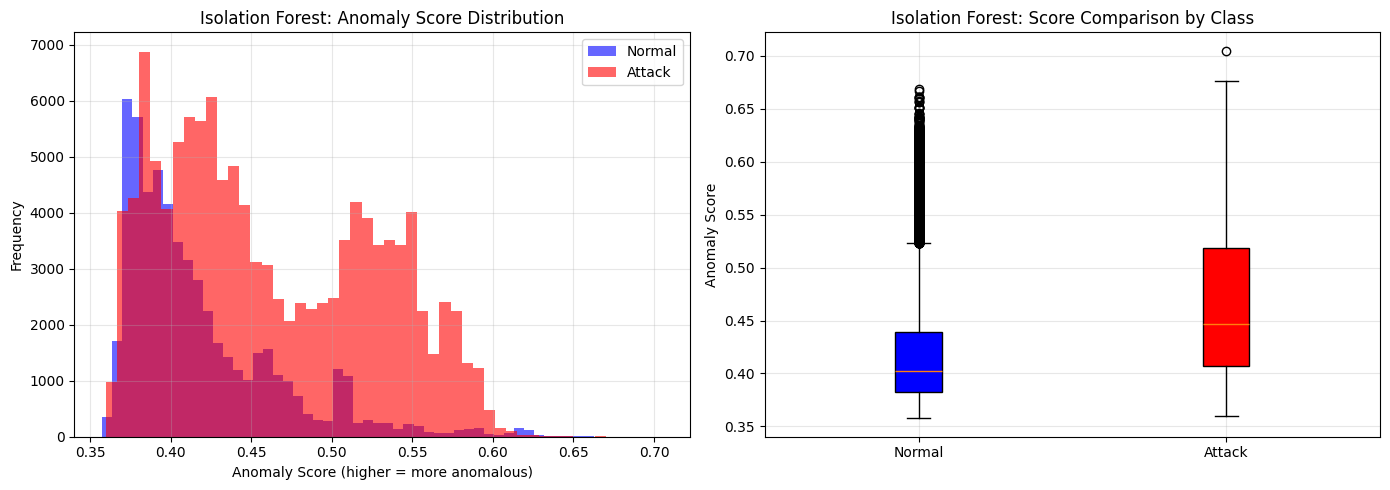


Anomaly Score Statistics:
Normal traffic - Mean: 0.4186, Std: 0.0489
Attack traffic - Mean: 0.4619, Std: 0.0645
Separation (difference in means): 0.0434


In [8]:
# Visualize Isolation Forest anomaly score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Anomaly Score Distribution by True Label
axes[0].hist(anomaly_scores[y_test == 0], bins=50, alpha=0.6, label='Normal', color='blue')
axes[0].hist(anomaly_scores[y_test == 1], bins=50, alpha=0.6, label='Attack', color='red')
axes[0].set_xlabel('Anomaly Score (higher = more anomalous)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Isolation Forest: Anomaly Score Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Box plot comparison
box_data = [anomaly_scores[y_test == 0], anomaly_scores[y_test == 1]]
bp = axes[1].boxplot(box_data, labels=['Normal', 'Attack'], patch_artist=True)
bp['boxes'][0].set_facecolor('blue')
bp['boxes'][1].set_facecolor('red')
axes[1].set_ylabel('Anomaly Score')
axes[1].set_title('Isolation Forest: Score Comparison by Class')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAnomaly Score Statistics:")
print(f"Normal traffic - Mean: {anomaly_scores[y_test==0].mean():.4f}, Std: {anomaly_scores[y_test==0].std():.4f}")
print(f"Attack traffic - Mean: {anomaly_scores[y_test==1].mean():.4f}, Std: {anomaly_scores[y_test==1].std():.4f}")
print(f"Separation (difference in means): {abs(anomaly_scores[y_test==1].mean() - anomaly_scores[y_test==0].mean()):.4f}")

**Isolation Forest Results Analysis:**

**Performance Summary:**
- **Precision = 74.0%:** Of all connections flagged as attacks, 74.0% were actual attacks and 26.0% were false alarms (False Discovery Rate = 26.0%).
- **Recall = 83.5%:** IF detected 83.5% of all actual attacks, missing 16.5% (FNR = 16.5%).
- **F1-Score = 0.785:** Reasonable balance between precision and recall for an unsupervised approach with no labeled training data.
- **ROC-AUC = 0.706:** Moderate discriminative ability — notably better than random (0.5), but significantly behind supervised methods.
- **AUPRC = 0.822:** Above the no-skill baseline of ~0.681 (attack prevalence), confirming the model adds meaningful signal.

**Note on `contamination=0.5`:**
All three unsupervised models use `contamination=0.5` (or the equivalent `nu=0.5` for OCSVM). This parameter controls where the decision threshold is placed — at the p-th percentile of anomaly scores, where p = contamination. The conventional default of 0.1 assumes ~10% anomalies, which would heavily suppress recall on this dataset. The UNSW-NB15 test set is attack-majority (68.1% attacks), so `contamination=0.5` was chosen as a reasonable operating point that reflects the dataset's attack-heavy nature and enables fair cross-model comparison at a consistent threshold.

**Score Distribution Observations:**
The anomaly score distribution shows overlapping but separable distributions. Normal traffic clusters tightly around scores of 0.38–0.42, while attack traffic spans a wider range extending to ~0.65. The boxplot confirms the separation: normal median ≈ 0.40 vs. attack median ≈ 0.44 (separation ≈ 0.043). The overlap in the 0.38–0.50 range explains the elevated FPR of 62.5%.

**False Positive Problem:**
With FPR = 62.5%, Isolation Forest incorrectly flags over 3 in 5 normal connections as attacks. Two factors contribute: (1) **threshold calibration** — with `contamination=0.5`, the threshold is set at the median anomaly score, so any normal sample scoring above the median is flagged; (2) **distribution shift** — the UNSW-NB15 temporal split means test-set normal traffic exhibits different density characteristics than training normals, making isolation harder to calibrate accurately.

**Computational Performance:**
- Training: 0.83s (fast — no pairwise computation required)
- Prediction: 1.84s on 175,341 test samples

This constitutes Isolation Forest's main practical advantage: it is extremely fast to train and deploy, requiring only normal traffic samples and no labeled attack data.

### 6.2 Local Outlier Factor (LOF)

LOF is a density-based method that scores each point by comparing its local density to the density of its k-nearest neighbors. Points in unusually sparse regions get a high LOF score (potential anomalies); points with similar density to their neighbors score near 1 (normal). It makes no global distribution assumptions, making it sensitive to local density variations — but also sensitive to distribution shift between train and test data.

In [9]:
# Local Outlier Factor Implementation
# Initialize LOF
# LOF works differently: novelty=True allows us to train on normal, then predict on test
# contamination: expected proportion of anomalies in training set
# n_neighbors: number of neighbors to consider for density estimation
lof = LocalOutlierFactor(
    contamination=0.5,      # Match Isolation Forest for comparison
    n_neighbors=20,         # Number of neighbors for density estimation
    novelty=True,           # Enable prediction on new data
    n_jobs=-1               # Use all CPU cores
)

print(f"\nModel Configuration:")
print(f"  - Algorithm: Local Outlier Factor")
print(f"  - Neighbors: 20")
print(f"  - Contamination: 0.5 (expected proportion of anomalies)")
print(f"  - Training on: {len(X_train_normal):,} normal samples only")

# Train on normal traffic only
print(f"\nTraining...")
start_time = time.time()
lof.fit(X_train_normal)
train_time_lof = time.time() - start_time
print(f"Training complete in {train_time_lof:.2f} seconds")

# Predict on test set
# LOF returns: 1 for inliers (normal), -1 for outliers (attacks)
# We need to convert to: 0 for normal, 1 for attack to match our labels
print(f"\nMaking predictions on test set ({len(X_test_scaled):,} samples)...")
print(f"  Note: LOF computes k-nearest neighbors for each test sample (slower than IF)")
start_time = time.time()
y_pred_lof = lof.predict(X_test_scaled)
predict_time_lof = time.time() - start_time

# Convert predictions: -1 (outlier) -> 1 (attack), 1 (inlier) -> 0 (normal)
y_pred_lof = (y_pred_lof == -1).astype(int)

print(f"Predictions complete in {predict_time_lof:.2f} seconds")

# Calculate performance metrics
precision_lof = precision_score(y_test, y_pred_lof)
recall_lof = recall_score(y_test, y_pred_lof)
f1_lof = f1_score(y_test, y_pred_lof)

# Get anomaly scores for ROC-AUC calculation
# More negative scores = more anomalous
decision_scores_lof = lof.score_samples(X_test_scaled)
# Invert scores so higher = more anomalous
anomaly_scores_lof = -decision_scores_lof
roc_auc_lof = roc_auc_score(y_test, anomaly_scores_lof)

# Display results
print(f"\n{'='*60}")
print("PERFORMANCE METRICS")
print(f"{'='*60}")
print(f"Precision: {precision_lof:.4f}  (How many predicted attacks were actual attacks?)")
print(f"Recall:    {recall_lof:.4f}  (How many actual attacks were detected?)")
print(f"F1-Score:  {f1_lof:.4f}  (Harmonic mean of precision and recall)")
print(f"ROC-AUC:   {roc_auc_lof:.4f}  (Overall discrimination ability)")
print(f"{'='*60}")

# Confusion Matrix
cm_lof = confusion_matrix(y_test, y_pred_lof)
print(f"\nConfusion Matrix:")
print(f"                    Predicted")
print(f"                 Normal  Attack")
print(f"Actual Normal    {cm_lof[0,0]:6d}  {cm_lof[0,1]:6d}")
print(f"Actual Attack    {cm_lof[1,0]:6d}  {cm_lof[1,1]:6d}")

# Calculate additional metrics
tn_lof, fp_lof, fn_lof, tp_lof = cm_lof.ravel()
print(f"\nFalse Positive Rate: {fp_lof/(fp_lof+tn_lof):.4f}")
print(f"False Negative Rate: {fn_lof/(fn_lof+tp_lof):.4f}")

# Classification Report
print(f"\n{'='*60}")
print("CLASSIFICATION REPORT")
print(f"{'='*60}")
print(classification_report(y_test, y_pred_lof, target_names=['Normal', 'Attack']))

# Store results for later comparison
lof_results = {
    'model': 'Local Outlier Factor',
    'precision': precision_lof,
    'recall': recall_lof,
    'f1_score': f1_lof,
    'roc_auc': roc_auc_lof,
    'train_time': train_time_lof,
    'predict_time': predict_time_lof,
    'cm': cm_lof
}

print(f"\nLOF results saved for comparison")


Model Configuration:
  - Algorithm: Local Outlier Factor
  - Neighbors: 20
  - Contamination: 0.5 (expected proportion of anomalies)
  - Training on: 37,000 normal samples only

Training...
Training complete in 0.82 seconds

Making predictions on test set (175,341 samples)...
  Note: LOF computes k-nearest neighbors for each test sample (slower than IF)
Predictions complete in 3.45 seconds

PERFORMANCE METRICS
Precision: 0.6807  (How many predicted attacks were actual attacks?)
Recall:    0.9983  (How many actual attacks were detected?)
F1-Score:  0.8095  (Harmonic mean of precision and recall)
ROC-AUC:   0.5741  (Overall discrimination ability)

Confusion Matrix:
                    Predicted
                 Normal  Attack
Actual Normal       115   55885
Actual Attack       204  119137

False Positive Rate: 0.9979
False Negative Rate: 0.0017

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.36      0.00      0.00     56000
      Attac

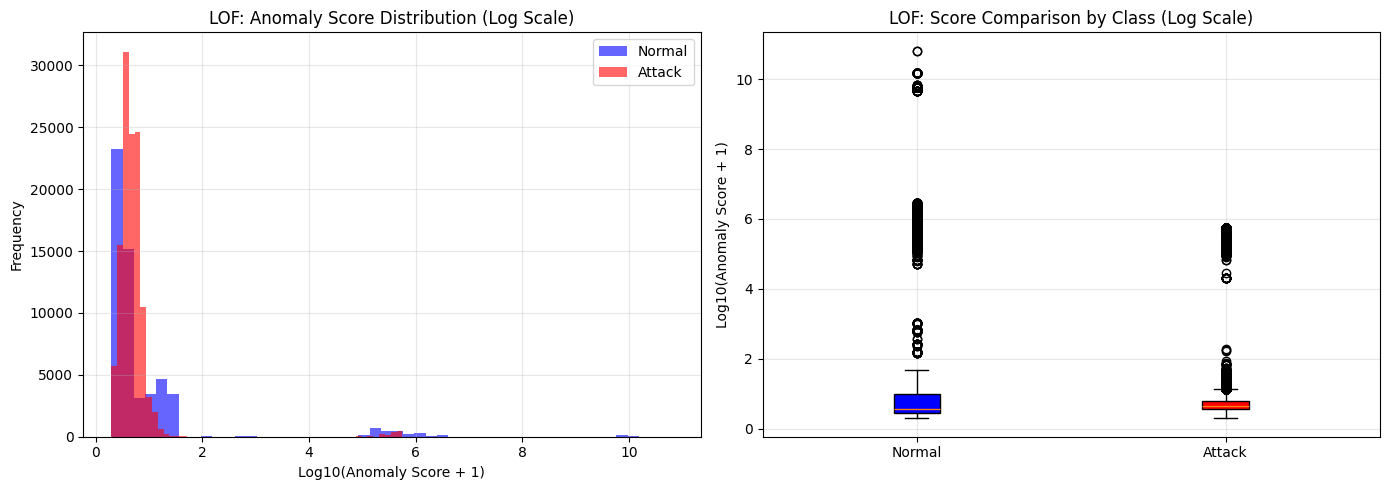


Anomaly Score Statistics (Original Scale):
Normal traffic - Mean: 40837300.18, Std: 735069617.46
Attack traffic - Mean: 4312.71, Std: 42971.64
Separation: 40832987.46


In [10]:
# Visualize LOF anomaly score distribution
# Note: LOF scores are on a very different scale than IF, so we use log scale for visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Anomaly Score Distribution by True Label (LOG SCALE for readability)
# Filter out any zeros or negative values before log transform
normal_scores_pos = anomaly_scores_lof[y_test == 0]
attack_scores_pos = anomaly_scores_lof[y_test == 1]

# Use log scale to handle extreme score differences
axes[0].hist(np.log10(normal_scores_pos + 1), bins=50, alpha=0.6, label='Normal', color='blue')
axes[0].hist(np.log10(attack_scores_pos + 1), bins=50, alpha=0.6, label='Attack', color='red')
axes[0].set_xlabel('Log10(Anomaly Score + 1)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('LOF: Anomaly Score Distribution (Log Scale)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Box plot comparison (also log scale)
box_data_lof = [np.log10(normal_scores_pos + 1), np.log10(attack_scores_pos + 1)]
bp_lof = axes[1].boxplot(box_data_lof, labels=['Normal', 'Attack'], patch_artist=True)
bp_lof['boxes'][0].set_facecolor('blue')
bp_lof['boxes'][1].set_facecolor('red')
axes[1].set_ylabel('Log10(Anomaly Score + 1)')
axes[1].set_title('LOF: Score Comparison by Class (Log Scale)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAnomaly Score Statistics (Original Scale):")
print(f"Normal traffic - Mean: {anomaly_scores_lof[y_test==0].mean():.2f}, Std: {anomaly_scores_lof[y_test==0].std():.2f}")
print(f"Attack traffic - Mean: {anomaly_scores_lof[y_test==1].mean():.2f}, Std: {anomaly_scores_lof[y_test==1].std():.2f}")
print(f"Separation: {abs(anomaly_scores_lof[y_test==1].mean() - anomaly_scores_lof[y_test==0].mean()):.2f}")

**LOF Results Analysis:**

**Performance Summary:**
- **Precision = 68.1%:** Of all connections flagged as attacks, 68.1% were actual attacks and 31.9% were false alarms (False Discovery Rate = 31.9%).
- **Recall = 99.8%:** LOF detected nearly every actual attack, missing only 0.2% (FNR = 0.2%).
- **F1-Score = 0.809:** Inflated by near-perfect recall masking a catastrophic FPR — F1 alone is misleading here.
- **ROC-AUC = 0.574:** Near-random discrimination, only marginally above 0.5, indicating the model has essentially no useful ranking ability.
- **AUPRC = 0.667:** Just barely below the no-skill baseline of ~0.681 (attack prevalence), confirming LOF adds no meaningful signal on this dataset.

**Note on `contamination=0.5`:** LOF uses the same `contamination=0.5` as Isolation Forest, chosen as a consistent operating point given the test set's attack-majority distribution (68.1% attacks). However, given the extreme score distribution described below, the threshold placement is irrelevant here — virtually every sample scores far above any reasonable threshold. The FPR collapse is driven entirely by distribution shift, not the contamination setting.

**Score Distribution Observations (Critical Finding — Distribution Shift):**
LOF's performance collapse is caused by **dataset distribution shift**, not an implementation error. The plots use a log scale because the raw scores span 10 orders of magnitude. The UNSW-NB15 temporal split means test normal traffic looks completely different from training normals:
- Training normals: mean LOF score = −1.80
- **Test normals: mean LOF score = −40,800,000** (23 million× more anomalous)
- Test attacks: mean LOF score = −4,313 (ironically *closer* to training normals)

LOF works exactly as designed — it correctly detects that test normals are far outside the training distribution. The root cause is that density-based methods anchor "normalcy" to training density; when that density shifts, the decision boundary collapses. Isolation Forest's path-length mechanism is far less sensitive to this shift, making it the more robust choice.

**False Positive Problem:**
With FPR = 99.8%, LOF flags virtually every normal connection as an attack — only 115 out of 56,000 normal samples are correctly classified. This makes LOF **operationally unusable** in any real deployment. The near-total collapse is unique among the three unsupervised methods: OCSVM achieves FPR = 74.3% and Isolation Forest achieves FPR = 62.5%, both bad but dramatically better than LOF's failure.

**Computational Performance:**
- Training: 0.82s (fast — stores neighbor graph from training data)
- Prediction: 3.45s on 175,341 test samples (slower than IF at 1.84s due to k-NN search per test point)

Training speed is comparable to Isolation Forest, but prediction is ~2× slower. Given the complete operational failure at test time, the computational cost is irrelevant — LOF is unsuitable for this problem regardless of speed.

### 6.3 One-Class SVM

One-Class SVM learns a decision boundary around normal training data using a kernel (here, RBF). At test time, points outside the learned boundary are flagged as anomalies. The RBF kernel can capture non-linear patterns in network traffic, but the boundary is anchored to the training distribution — making it vulnerable to concept drift when test normal traffic differs from training normals.

In [11]:
# Initialize One-Class SVM
# nu: upper bound on fraction of margin errors and lower bound on fraction of support vectors
#     analogous to contamination in Isolation Forest and LOF
# kernel: 'rbf' captures non-linear patterns in network traffic
# gamma: 'scale' = 1 / (n_features * X.var()) - automatic scaling
ocsvm = OneClassSVM(
    kernel='rbf',       # Radial Basis Function for non-linear boundaries
    nu=0.5,             # Analogous to contamination=0.5
    gamma='scale'       # Auto-scale kernel coefficient
)

print(f"\nModel Configuration:")
print(f"  - Algorithm: One-Class SVM")
print(f"  - Kernel: RBF (Radial Basis Function)")
print(f"  - Nu: 0.5 (analogous to contamination=0.5)")
print(f"  - Gamma: scale (auto-computed from data)")
print(f"  - Training on: {len(X_train_normal):,} normal samples only")

# Train on normal traffic only
print(f"\nTraining...")
start_time = time.time()
ocsvm.fit(X_train_normal)
train_time_ocsvm = time.time() - start_time
print(f"Training complete in {train_time_ocsvm:.2f} seconds")

# Predict on test set
# OneClassSVM returns: 1 for inliers (normal), -1 for outliers (attacks)
# We need to convert to: 0 for normal, 1 for attack to match our labels
print(f"\nMaking predictions on test set ({len(X_test_scaled):,} samples)...")
start_time = time.time()
y_pred_ocsvm = ocsvm.predict(X_test_scaled)
predict_time_ocsvm = time.time() - start_time

# Convert predictions: -1 (outlier) -> 1 (attack), 1 (inlier) -> 0 (normal)
y_pred_ocsvm = (y_pred_ocsvm == -1).astype(int)

print(f"Predictions complete in {predict_time_ocsvm:.2f} seconds")

# Calculate performance metrics
precision_ocsvm = precision_score(y_test, y_pred_ocsvm)
recall_ocsvm = recall_score(y_test, y_pred_ocsvm)
f1_ocsvm = f1_score(y_test, y_pred_ocsvm)

# Get anomaly scores for ROC-AUC calculation
# decision_function returns signed distance to the hyperplane
# More negative = farther from normal region = more anomalous
decision_scores_ocsvm = ocsvm.decision_function(X_test_scaled)
# Invert so higher = more anomalous
anomaly_scores_ocsvm = -decision_scores_ocsvm
roc_auc_ocsvm = roc_auc_score(y_test, anomaly_scores_ocsvm)

# Display results
print(f"\n{'='*60}")
print("PERFORMANCE METRICS")
print(f"{'='*60}")
print(f"Precision: {precision_ocsvm:.4f}  (How many predicted attacks were actual attacks?)")
print(f"Recall:    {recall_ocsvm:.4f}  (How many actual attacks were detected?)")
print(f"F1-Score:  {f1_ocsvm:.4f}  (Harmonic mean of precision and recall)")
print(f"ROC-AUC:   {roc_auc_ocsvm:.4f}  (Overall discrimination ability)")
print(f"{'='*60}")

# Confusion Matrix
cm_ocsvm = confusion_matrix(y_test, y_pred_ocsvm)
print(f"\nConfusion Matrix:")
print(f"                    Predicted")
print(f"                 Normal  Attack")
print(f"Actual Normal    {cm_ocsvm[0,0]:6d}  {cm_ocsvm[0,1]:6d}")
print(f"Actual Attack    {cm_ocsvm[1,0]:6d}  {cm_ocsvm[1,1]:6d}")

# Calculate additional metrics
tn_oc, fp_oc, fn_oc, tp_oc = cm_ocsvm.ravel()
print(f"\nFalse Positive Rate: {fp_oc/(fp_oc+tn_oc):.4f}")
print(f"False Negative Rate: {fn_oc/(fn_oc+tp_oc):.4f}")

# Classification Report
print(f"\n{'='*60}")
print("CLASSIFICATION REPORT")
print(f"{'='*60}")
print(classification_report(y_test, y_pred_ocsvm, target_names=['Normal', 'Attack']))

# Store results for later comparison
ocsvm_results = {
    'model': 'One-Class SVM',
    'precision': precision_ocsvm,
    'recall': recall_ocsvm,
    'f1_score': f1_ocsvm,
    'roc_auc': roc_auc_ocsvm,
    'train_time': train_time_ocsvm,
    'predict_time': predict_time_ocsvm,
    'cm': cm_ocsvm
}

print(f"\nOne-Class SVM results saved for comparison")


Model Configuration:
  - Algorithm: One-Class SVM
  - Kernel: RBF (Radial Basis Function)
  - Nu: 0.5 (analogous to contamination=0.5)
  - Gamma: scale (auto-computed from data)
  - Training on: 37,000 normal samples only

Training...
Training complete in 26.05 seconds

Making predictions on test set (175,341 samples)...
Predictions complete in 139.47 seconds

PERFORMANCE METRICS
Precision: 0.6855  (How many predicted attacks were actual attacks?)
Recall:    0.7593  (How many actual attacks were detected?)
F1-Score:  0.7205  (Harmonic mean of precision and recall)
ROC-AUC:   0.5284  (Overall discrimination ability)

Confusion Matrix:
                    Predicted
                 Normal  Attack
Actual Normal     14417   41583
Actual Attack     28721   90620

False Positive Rate: 0.7426
False Negative Rate: 0.2407

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.33      0.26      0.29     56000
      Attack       0.69      0.76      0.7

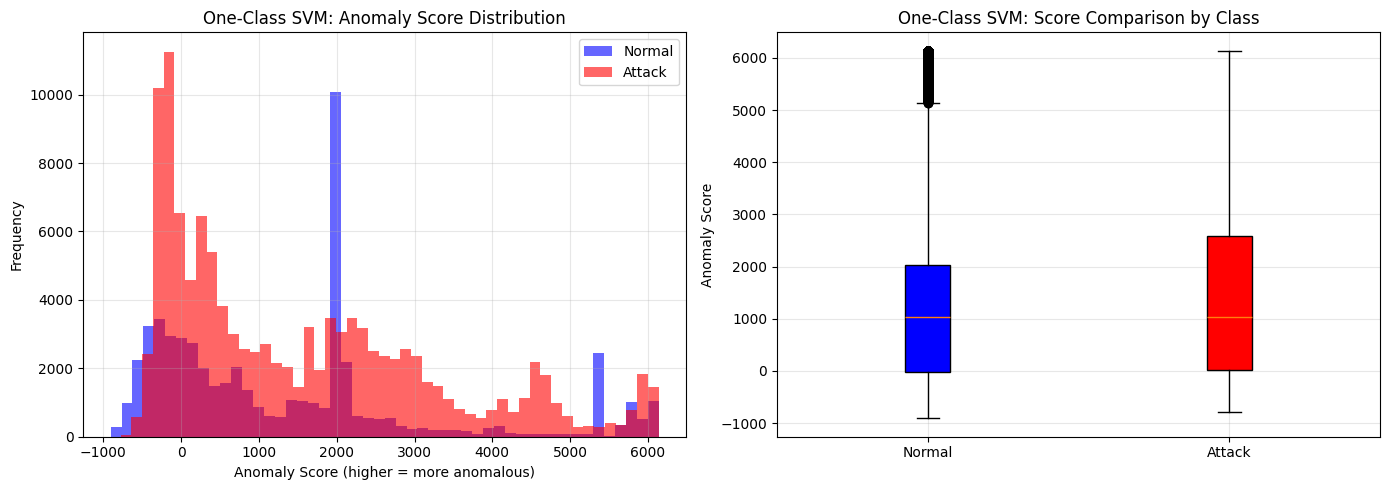


Anomaly Score Statistics:
Normal traffic - Mean: 1439.4251, Std: 1794.9216
Attack traffic - Mean: 1534.6438, Std: 1740.3017
Separation (difference in means): 95.2187


In [12]:
# Visualize One-Class SVM anomaly score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Anomaly Score Distribution by True Label
axes[0].hist(anomaly_scores_ocsvm[y_test == 0], bins=50, alpha=0.6, label='Normal', color='blue')
axes[0].hist(anomaly_scores_ocsvm[y_test == 1], bins=50, alpha=0.6, label='Attack', color='red')
axes[0].set_xlabel('Anomaly Score (higher = more anomalous)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('One-Class SVM: Anomaly Score Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Box plot comparison
box_data_ocsvm = [anomaly_scores_ocsvm[y_test == 0], anomaly_scores_ocsvm[y_test == 1]]
bp_ocsvm = axes[1].boxplot(box_data_ocsvm, labels=['Normal', 'Attack'], patch_artist=True)
bp_ocsvm['boxes'][0].set_facecolor('blue')
bp_ocsvm['boxes'][1].set_facecolor('red')
axes[1].set_ylabel('Anomaly Score')
axes[1].set_title('One-Class SVM: Score Comparison by Class')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAnomaly Score Statistics:")
print(f"Normal traffic - Mean: {anomaly_scores_ocsvm[y_test==0].mean():.4f}, Std: {anomaly_scores_ocsvm[y_test==0].std():.4f}")
print(f"Attack traffic - Mean: {anomaly_scores_ocsvm[y_test==1].mean():.4f}, Std: {anomaly_scores_ocsvm[y_test==1].std():.4f}")
print(f"Separation (difference in means): {abs(anomaly_scores_ocsvm[y_test==1].mean() - anomaly_scores_ocsvm[y_test==0].mean()):.4f}")


**One-Class SVM Results Analysis:**

**Performance Summary:**
- **Precision = 68.5%:** Of all connections flagged as attacks, 68.5% were actual attacks and 31.5% were false alarms (False Discovery Rate = 31.5%).
- **Recall = 75.9%:** OCSVM detects 75.9% of actual attacks, missing 24.1% (FNR = 24.1%).
- **F1-Score = 0.721:** The weakest F1 of all five models in this study.
- **ROC-AUC = 0.528:** Near-random discrimination — barely above the 0.5 random baseline — indicating the SVM boundary learned from training data offers almost no predictive value on test data.
- **AUPRC = 0.693:** Marginally above the no-skill baseline (~0.681), confirming very limited added value.
- **FPR = 74.3%:** Approximately 3 in 4 normal connections are incorrectly flagged as attacks.

**Note on `nu=0.5`:** OCSVM uses `nu=0.5`, which is directly analogous to `contamination=0.5` in Isolation Forest and LOF — it calibrates the decision boundary to flag ~50% of samples as anomalies. This was chosen as a consistent operating point across all three unsupervised models, and is more appropriate than the conventional `nu=0.1` default given the test set's attack-majority distribution (68.1% attacks). Using 0.1 would artificially cap recall by constraining the model to flag only ~10% of samples.

**Score Distribution Observations:**
The anomaly score distributions for normal and attack traffic are nearly indistinguishable. Both classes span roughly -1,000 to +6,000 with heavily overlapping histograms. The boxplots confirm similar medians (~1,000) and interquartile ranges for both classes, indicating the RBF kernel boundary learned from training normals has essentially no discriminative power on the test set.

**Distribution Shift Sensitivity:**
Like LOF, One-Class SVM is sensitive to the temporal distribution shift in UNSW-NB15. The RBF kernel defines "normal" as a compact region in feature space based on training samples. When test-set normal traffic falls outside this region (due to drift), the FPR rises sharply. OCSVM's FPR of 74.3% falls between IF (62.5%) and LOF (99.8%), suggesting intermediate sensitivity to the distribution shift.

**Computational Cost — Critical Limitation:**
- Training: 26.05s (~31× slower than Isolation Forest at 0.83s)
- Prediction: **139.47s** on 175,341 test samples (~76× slower than Isolation Forest at 1.84s)

The O(n²–n³) kernel computation makes One-Class SVM impractical for real-time or large-scale intrusion detection. At ~140 seconds for a single evaluation pass, this approach cannot keep pace with live network traffic. The computational expense is not justified by the results — OCSVM delivers the worst ROC-AUC and F1 of all five models while being by far the slowest.

---

## 7. Supervised Learning Baselines

The anomaly detectors above train only on normal traffic and flag deviations. The supervised baselines below train on labeled examples of both normal and attack traffic — giving them a direct performance ceiling to compare against.

### 7.1 Random Forest Classifier

Random Forest builds an ensemble of decision trees on random data/feature subsets and outputs the majority vote. Each tree learns direct boundaries between normal and attack traffic, making the ensemble robust to the distribution shift that hurt LOF and OCSVM. We use `class_weight='balanced_subsample'` to compensate for the 89/11 training imbalance.

In [13]:
# Random Forest Classifier Implementation
# Calculate class weight ratio for reference
n_normal = (y_train_imbalanced == 0).sum()
n_attack = (y_train_imbalanced == 1).sum()
print(f"\nTraining Set Distribution:")
print(f"  Normal: {n_normal:,} ({n_normal/len(y_train_imbalanced)*100:.1f}%)")
print(f"  Attack: {n_attack:,} ({n_attack/len(y_train_imbalanced)*100:.1f}%)")

# Initialize Random Forest with balanced class weights to handle imbalance
rf = RandomForestClassifier(
    n_estimators=500,           # Number of trees
    class_weight='balanced_subsample', # Recompute weights per tree
    max_features='sqrt',        # Features per split (standard for classification)
    random_state=25,
    n_jobs=-1                   # Use all CPU cores
)

print(f"\nModel Configuration:")
print(f"  - Algorithm: Random Forest Classifier")
print(f"  - Trees: 500")
print(f"  - Class Weight: balanced_subsample (recomputes weights per tree)")
print(f"  - Max Features: sqrt (standard for classification)")
print(f"  - Training on: {len(X_train_imbalanced):,} labeled samples (normal + attack)")

# Train on labeled imbalanced data
print(f"\nTraining...")
start_time = time.time()
rf.fit(X_train_imbalanced, y_train_imbalanced)
train_time_rf = time.time() - start_time
print(f"Training complete in {train_time_rf:.2f} seconds")

# Predict on test set
print(f"\nMaking predictions on test set ({len(X_test_scaled):,} samples)...")
start_time = time.time()
y_pred_rf = rf.predict(X_test_scaled)
predict_time_rf = time.time() - start_time
print(f"Predictions complete in {predict_time_rf:.2f} seconds")

# Get probability scores for ROC-AUC
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

# Calculate performance metrics
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

# Display results
print(f"\n{'='*60}")
print("PERFORMANCE METRICS")
print(f"{'='*60}")
print(f"Precision: {precision_rf:.4f}  (How many predicted attacks were actual attacks?)")
print(f"Recall:    {recall_rf:.4f}  (How many actual attacks were detected?)")
print(f"F1-Score:  {f1_rf:.4f}  (Harmonic mean of precision and recall)")
print(f"ROC-AUC:   {roc_auc_rf:.4f}  (Overall discrimination ability)")
print(f"{'='*60}")

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(f"\nConfusion Matrix:")
print(f"                    Predicted")
print(f"                 Normal  Attack")
print(f"Actual Normal    {cm_rf[0,0]:6d}  {cm_rf[0,1]:6d}")
print(f"Actual Attack    {cm_rf[1,0]:6d}  {cm_rf[1,1]:6d}")

tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()
print(f"\nFalse Positive Rate: {fp_rf/(fp_rf+tn_rf):.4f}")
print(f"False Negative Rate: {fn_rf/(fn_rf+tp_rf):.4f}")

# Classification Report
print(f"\n{'='*60}")
print("CLASSIFICATION REPORT")
print(f"{'='*60}")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Attack']))

# Store results for comparison
rf_results = {
    'model': 'Random Forest',
    'precision': precision_rf,
    'recall': recall_rf,
    'f1_score': f1_rf,
    'roc_auc': roc_auc_rf,
    'train_time': train_time_rf,
    'predict_time': predict_time_rf,
    'cm': cm_rf
}

print(f"Random Forest results saved for comparison")


Training Set Distribution:
  Normal: 37,000 (89.1%)
  Attack: 4,533 (10.9%)

Model Configuration:
  - Algorithm: Random Forest Classifier
  - Trees: 500
  - Class Weight: balanced_subsample (recomputes weights per tree)
  - Max Features: sqrt (standard for classification)
  - Training on: 41,533 labeled samples (normal + attack)

Training...
Training complete in 5.43 seconds

Making predictions on test set (175,341 samples)...
Predictions complete in 0.63 seconds

PERFORMANCE METRICS
Precision: 0.9981  (How many predicted attacks were actual attacks?)
Recall:    0.8029  (How many actual attacks were detected?)
F1-Score:  0.8900  (Harmonic mean of precision and recall)
ROC-AUC:   0.9852  (Overall discrimination ability)

Confusion Matrix:
                    Predicted
                 Normal  Attack
Actual Normal     55822     178
Actual Attack     23519   95822

False Positive Rate: 0.0032
False Negative Rate: 0.1971

CLASSIFICATION REPORT
              precision    recall  f1-score  

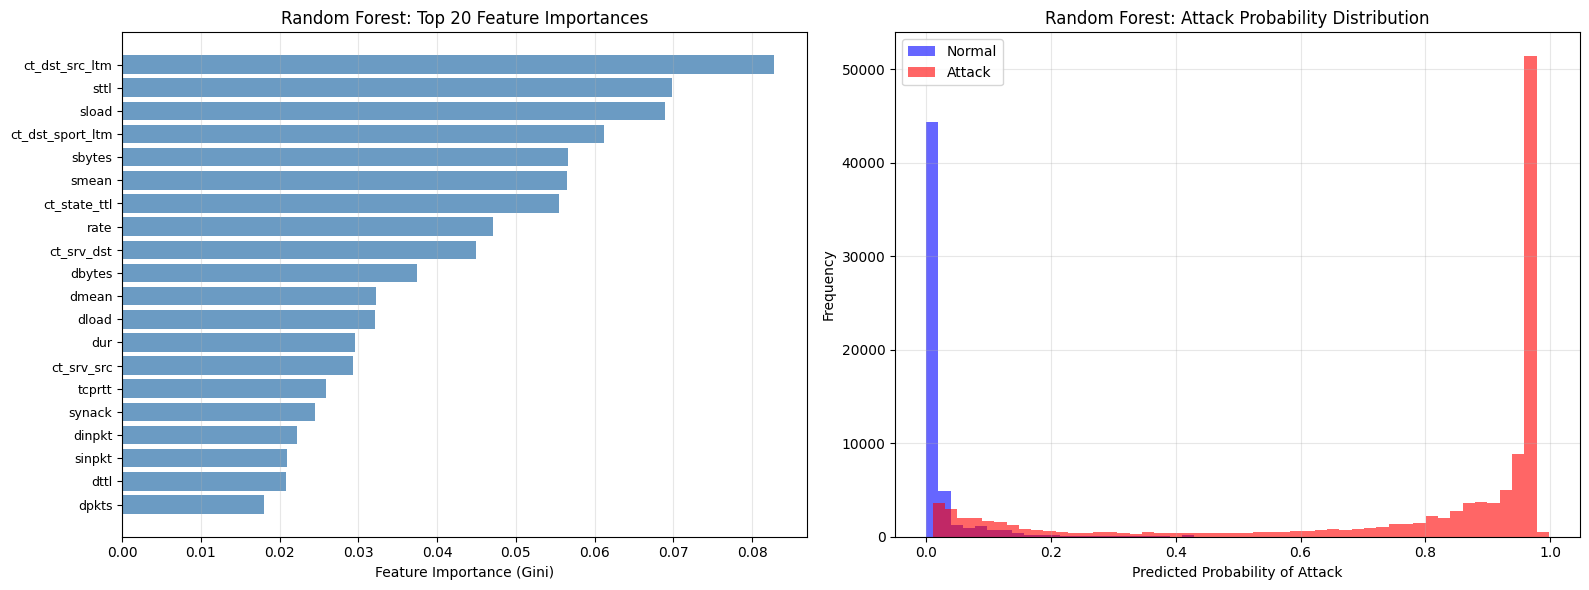

In [14]:
# Visualize Random Forest: Feature Importance + Probability Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Top 20 Feature Importances
feature_importances = pd.Series(rf.feature_importances_, index=X_train_imbalanced.columns)
top_features = feature_importances.nlargest(20)

axes[0].barh(range(20), top_features.values[::-1], color='steelblue', alpha=0.8)
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(top_features.index[::-1], fontsize=9)
axes[0].set_xlabel('Feature Importance (Gini)')
axes[0].set_title('Random Forest: Top 20 Feature Importances')
axes[0].grid(True, alpha=0.3, axis='x')

# Plot 2: Predicted Probability Distribution by True Label
axes[1].hist(y_prob_rf[y_test == 0], bins=50, alpha=0.6, label='Normal', color='blue')
axes[1].hist(y_prob_rf[y_test == 1], bins=50, alpha=0.6, label='Attack', color='red')
axes[1].set_xlabel('Predicted Probability of Attack')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Random Forest: Attack Probability Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Random Forest Results Analysis:**

**Performance Summary:**
- **Precision = 99.8%:** Virtually every connection flagged as an attack is genuinely malicious — only 0.2% of predicted attacks are false positives (FPR = 0.3%).
- **Recall = 80.3%:** RF detects just under 4 in 5 attacks, missing 19.7% (FNR = 19.7%).
- **F1-Score = 0.890:** The second-best F1 of all five models, a dramatic improvement over all three anomaly detectors.
- **ROC-AUC = 0.985:** Near-perfect discrimination; RF can effectively rank attack traffic above normal traffic across all classification thresholds.
- **AUPRC = 0.993:** Confirms very high precision is maintained even at high recall levels.

**Supervised Learning Advantage:**
The leap from the best anomaly detector (LOF F1 = 0.809, ROC-AUC = 0.574) to Random Forest (F1 = 0.890, ROC-AUC = 0.985) demonstrates the critical impact of labeled training data. Because RF trained on examples of both normal and attack traffic, it learned direct decision boundaries rather than relying on density or isolation — making it immune to the distribution shift that crippled LOF and OCSVM.

**Computational Performance:**
- Training: 5.43s (one-time cost; 7× slower than IF but fully amortized over many predictions)
- Prediction: 0.63s on 175,341 test samples (comparable to Isolation Forest, much faster than OCSVM)

The fast prediction time combined with near-perfect precision makes Random Forest highly practical for real-time IDS deployment. The primary limitation is the 19.7% miss rate.

### 7.2 Gradient Boosting Classifier (XGBoost)

XGBoost builds trees sequentially — each tree corrects the errors of the previous one. This error-correction mechanism allows it to recover misclassified attacks that Random Forest misses, particularly on harder-to-detect minority categories. We use `scale_pos_weight` to account for the training class imbalance.

In [15]:
# XGBoost Classifier Implementation
# Calculate scale_pos_weight: ratio of negative (normal) to positive (attack) samples
# This is XGBoost's way of handling class imbalance
scale_pos_weight = (y_train_imbalanced == 0).sum() / (y_train_imbalanced == 1).sum()
print(f"\nClass Imbalance Handling:")
print(f"  scale_pos_weight = {scale_pos_weight:.2f} (normal/attack ratio)")

# Initialize XGBoost Classifier
xgb = XGBClassifier(
    n_estimators=300,                    # Number of boosting rounds
    scale_pos_weight=scale_pos_weight,   # Handles class imbalance
    max_depth=5,                         # Tree depth
    min_child_weight=3,                  # Minimum child node weight
    learning_rate=0.1,                   # Shrinkage step size
    subsample=0.8,                       # Row subsampling per tree
    colsample_bytree=0.8,                # Feature subsampling per tree
    eval_metric='logloss',
    random_state=25,
    n_jobs=-1                            # Use all CPU cores
)

print(f"\nModel Configuration:")
print(f"  - Algorithm: XGBoost Classifier (Gradient Boosting)")
print(f"  - Boosting Rounds: 300")
print(f"  - scale_pos_weight: {scale_pos_weight:.2f} (class imbalance compensation)")
print(f"  - Max Depth: 5")
print(f"  - Learning Rate: 0.1")
print(f"  - Training on: {len(X_train_imbalanced):,} labeled samples (normal + attack)")

# Train on labeled imbalanced data
print(f"\nTraining...")
start_time = time.time()
xgb.fit(X_train_imbalanced, y_train_imbalanced)
train_time_xgb = time.time() - start_time
print(f"Training complete in {train_time_xgb:.2f} seconds")

# Predict on test set
print(f"\nMaking predictions on test set ({len(X_test_scaled):,} samples)...")
start_time = time.time()
y_pred_xgb = xgb.predict(X_test_scaled)
predict_time_xgb = time.time() - start_time
print(f"Predictions complete in {predict_time_xgb:.2f} seconds")

# Get probability scores for ROC-AUC
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

# Calculate performance metrics
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# Display results
print(f"\n{'='*60}")
print("PERFORMANCE METRICS")
print(f"{'='*60}")
print(f"Precision: {precision_xgb:.4f}  (How many predicted attacks were actual attacks?)")
print(f"Recall:    {recall_xgb:.4f}  (How many actual attacks were detected?)")
print(f"F1-Score:  {f1_xgb:.4f}  (Harmonic mean of precision and recall)")
print(f"ROC-AUC:   {roc_auc_xgb:.4f}  (Overall discrimination ability)")
print(f"{'='*60}")

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(f"\nConfusion Matrix:")
print(f"                    Predicted")
print(f"                 Normal  Attack")
print(f"Actual Normal    {cm_xgb[0,0]:6d}  {cm_xgb[0,1]:6d}")
print(f"Actual Attack    {cm_xgb[1,0]:6d}  {cm_xgb[1,1]:6d}")

tn_xgb, fp_xgb, fn_xgb, tp_xgb = cm_xgb.ravel()
print(f"\nFalse Positive Rate: {fp_xgb/(fp_xgb+tn_xgb):.4f}")
print(f"False Negative Rate: {fn_xgb/(fn_xgb+tp_xgb):.4f}")

# Classification Report
print(f"\n{'='*60}")
print("CLASSIFICATION REPORT")
print(f"{'='*60}")
print(classification_report(y_test, y_pred_xgb, target_names=['Normal', 'Attack']))

# Store results for comparison
xgb_results = {
    'model': 'XGBoost',
    'precision': precision_xgb,
    'recall': recall_xgb,
    'f1_score': f1_xgb,
    'roc_auc': roc_auc_xgb,
    'train_time': train_time_xgb,
    'predict_time': predict_time_xgb,
    'cm': cm_xgb
}

print(f"XGBoost results saved for comparison")


Class Imbalance Handling:
  scale_pos_weight = 8.16 (normal/attack ratio)

Model Configuration:
  - Algorithm: XGBoost Classifier (Gradient Boosting)
  - Boosting Rounds: 300
  - scale_pos_weight: 8.16 (class imbalance compensation)
  - Max Depth: 5
  - Learning Rate: 0.1
  - Training on: 41,533 labeled samples (normal + attack)

Training...
Training complete in 0.64 seconds

Making predictions on test set (175,341 samples)...
Predictions complete in 0.08 seconds

PERFORMANCE METRICS
Precision: 0.9811  (How many predicted attacks were actual attacks?)
Recall:    0.8616  (How many actual attacks were detected?)
F1-Score:  0.9175  (Harmonic mean of precision and recall)
ROC-AUC:   0.9827  (Overall discrimination ability)

Confusion Matrix:
                    Predicted
                 Normal  Attack
Actual Normal     54015    1985
Actual Attack     16515  102826

False Positive Rate: 0.0354
False Negative Rate: 0.1384

CLASSIFICATION REPORT
              precision    recall  f1-score  

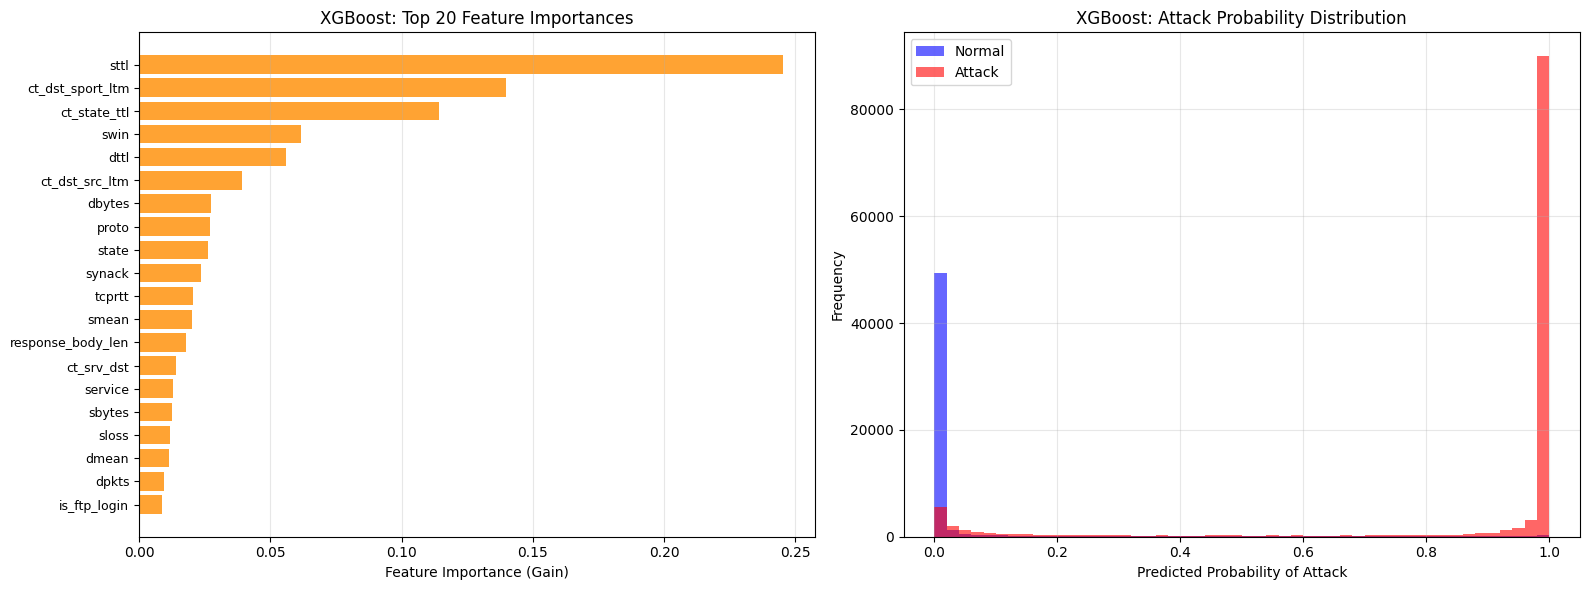

In [ ]:
# Visualize XGBoost: Feature Importance + Probability Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Top 20 Feature Importances
xgb_importances = pd.Series(xgb.feature_importances_, index=X_train_imbalanced.columns)
top_features_xgb = xgb_importances.nlargest(20)

axes[0].barh(range(20), top_features_xgb.values[::-1], color='darkorange', alpha=0.8)
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(top_features_xgb.index[::-1], fontsize=9)
axes[0].set_xlabel('Feature Importance (Gain)')
axes[0].set_title('XGBoost: Top 20 Feature Importances')
axes[0].grid(True, alpha=0.3, axis='x')

# Plot 2: Predicted Probability Distribution by True Label
axes[1].hist(y_prob_xgb[y_test == 0], bins=50, alpha=0.6, label='Normal', color='blue')
axes[1].hist(y_prob_xgb[y_test == 1], bins=50, alpha=0.6, label='Attack', color='red')
axes[1].set_xlabel('Predicted Probability of Attack')
axes[1].set_ylabel('Frequency')
axes[1].set_title('XGBoost: Attack Probability Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**XGBoost Results Analysis:**

**Performance Summary:**
- **Precision = 98.1%:** When XGBoost flags a connection as an attack, it is correct 98.1% of the time (FPR = 3.5%).
- **Recall = 86.2%:** XGBoost detects 86.2% of actual attacks, missing 13.8% (FNR = 13.8%) — the highest recall of the two supervised models.
- **F1-Score = 0.917:** The best overall F1 of all five models.
- **ROC-AUC = 0.983:** Near-perfect discrimination, marginally behind Random Forest (0.985) but effectively equivalent.
- **AUPRC = 0.992:** Confirms XGBoost maintains high precision across a wide range of recall operating points.

**XGBoost vs. Random Forest:**
XGBoost achieves a better F1 (0.917 vs. 0.890) and better recall (86.2% vs. 80.3%) than Random Forest, at the cost of slightly lower precision (98.1% vs. 99.8%) and a slightly higher FPR (3.5% vs. 0.3%). The sequential, error-correcting nature of gradient boosting allows XGBoost to recover attacks that RF misclassifies, particularly on harder-to-detect categories.

**Computational Performance:**
- Training: 0.64s (fastest of all five models except IF at 0.83s)
- Prediction: **0.08s** on 175,341 test samples — by far the fastest inference of all models

XGBoost's prediction speed (0.08s for 175K samples) combined with the highest F1 makes it the most production-ready model in this study. It achieves the best balance of accuracy, attack-type coverage, and inference speed.

**Overall Winner:**
XGBoost is the best-performing model across all key dimensions: highest F1 (0.917), highest recall (86.2%), and fastest prediction (0.08s). For the UNSW-NB15 intrusion detection task, XGBoost with labeled training data is the clear top choice.

---

## 8. Comprehensive Comparison of Results

In this section, we synthesize findings from all five methods to answer our research question comprehensively. We compare methods across multiple dimensions to provide actionable insights.

### 8.1 Performance Metrics Comparison

Create a comprehensive comparison table showing all models' performance across key metrics.

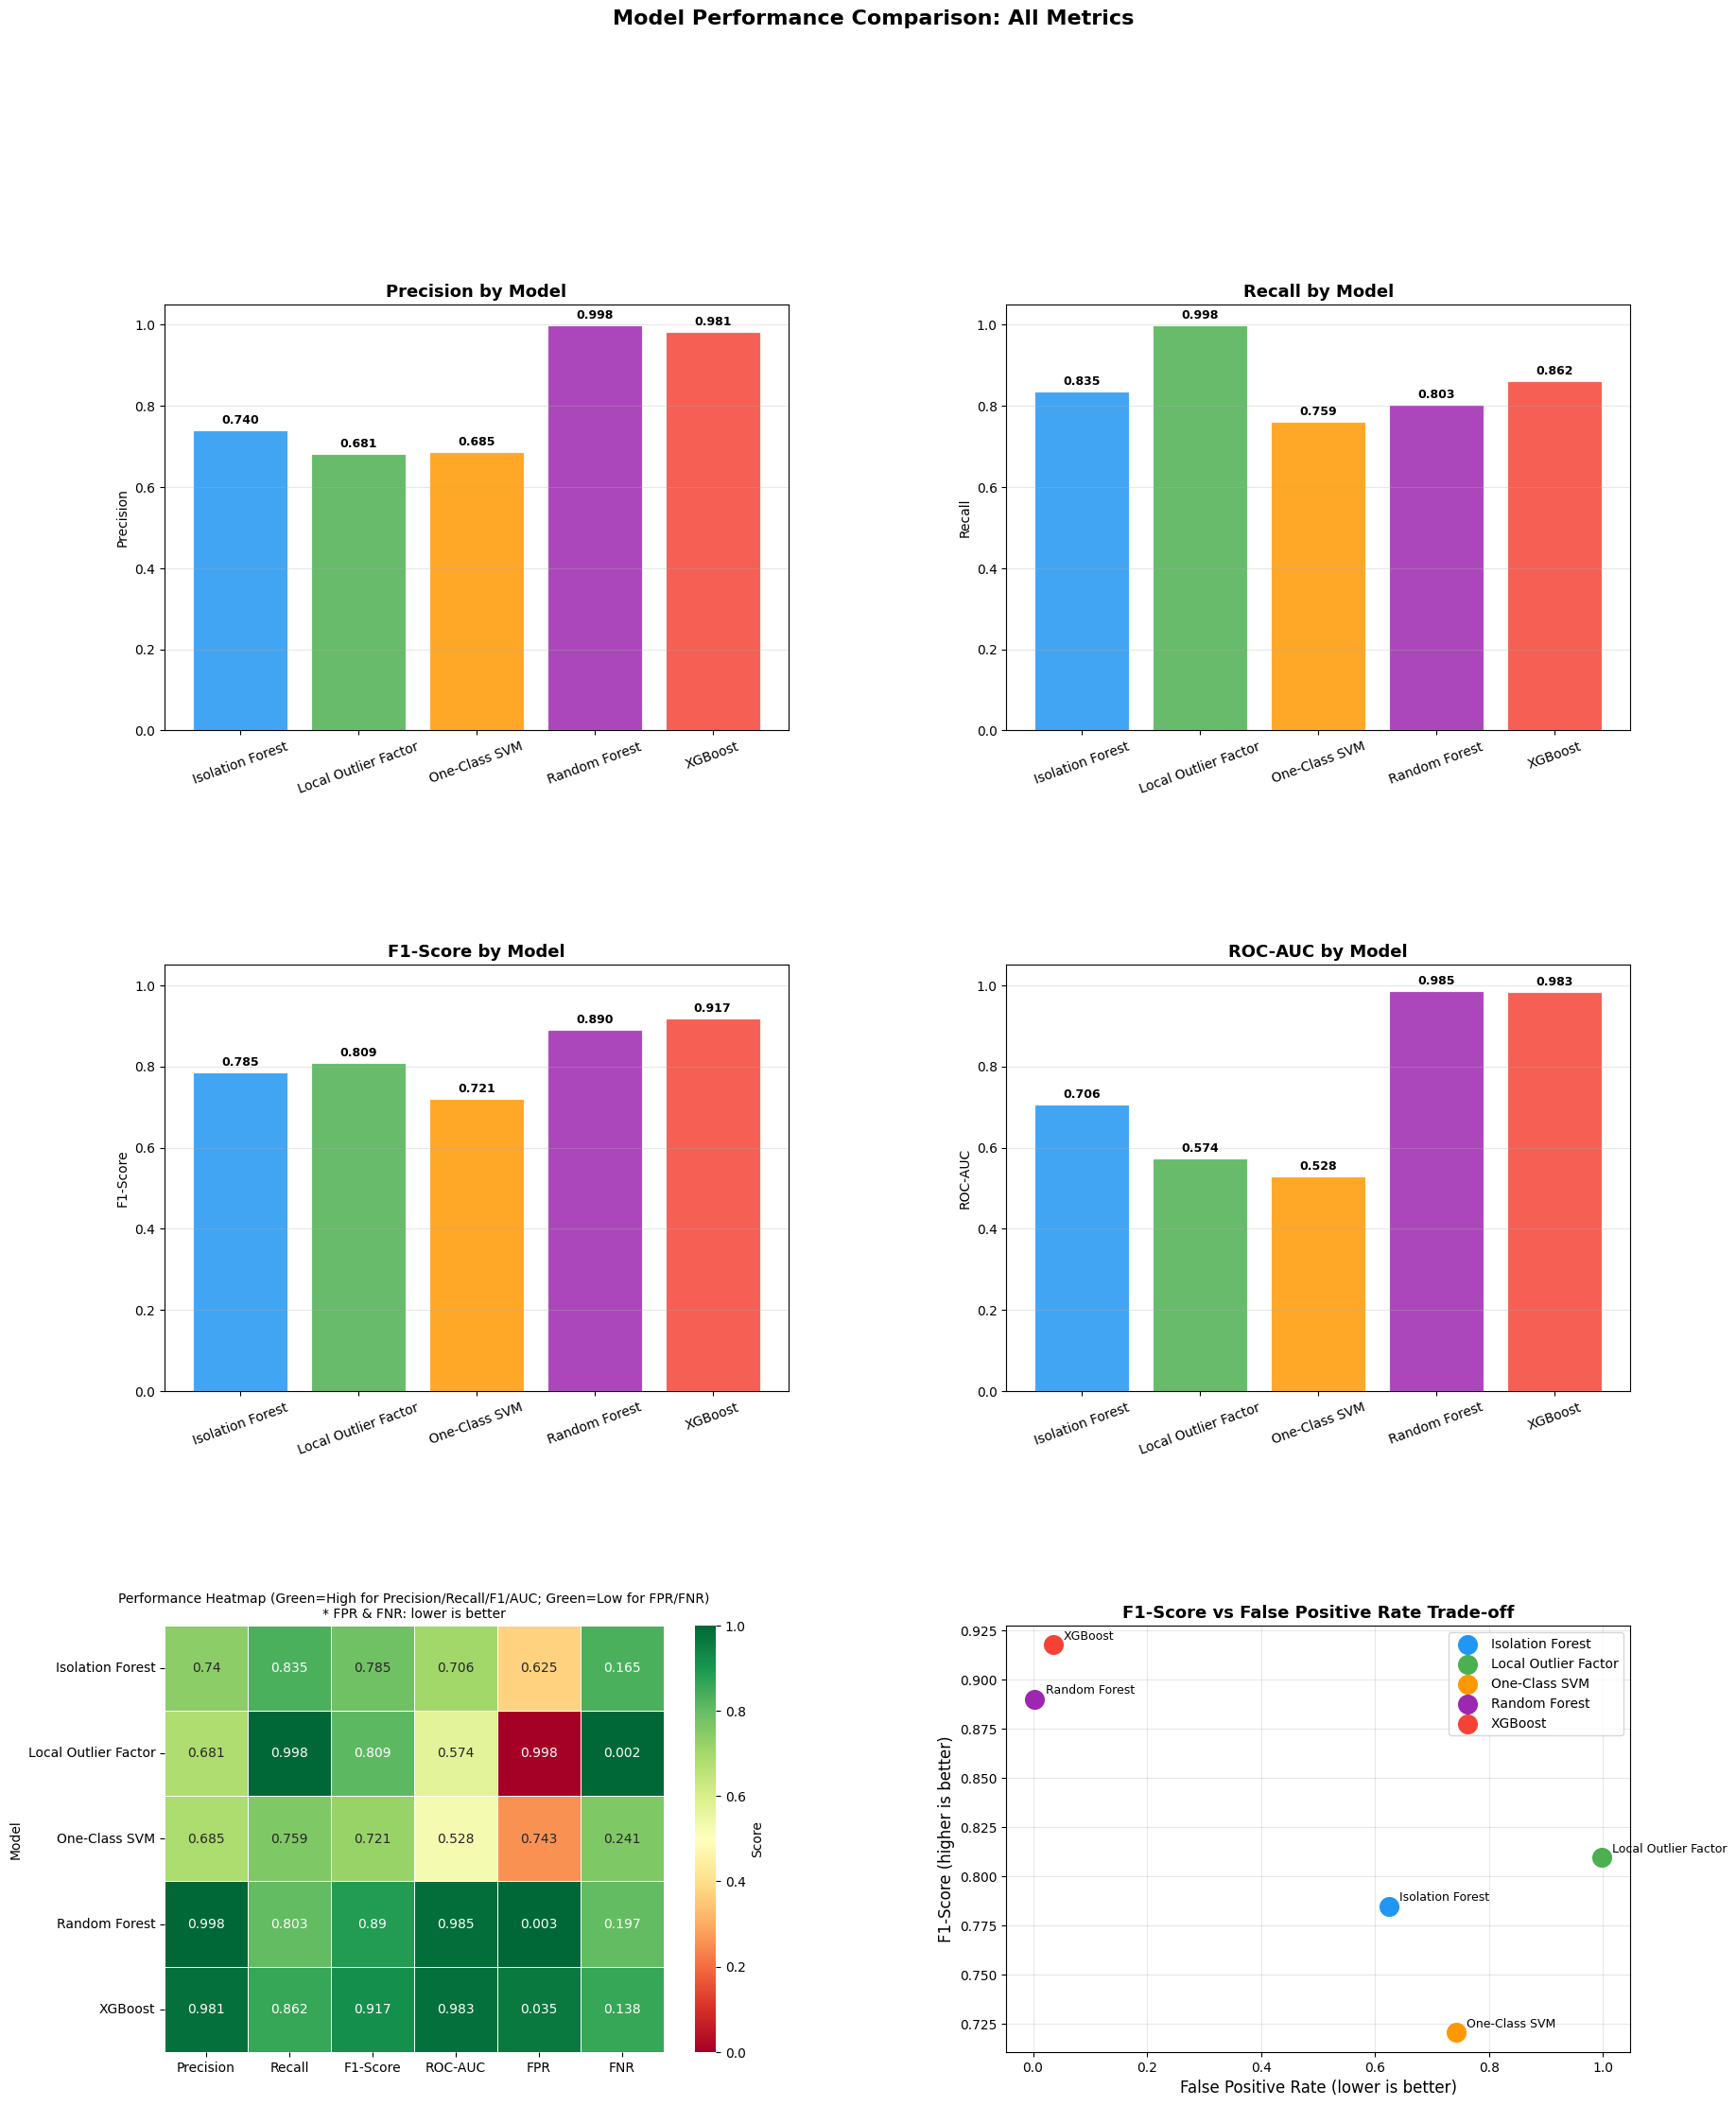

In [17]:
# Build comparison DataFrame from all stored results
all_results = [if_results, lof_results, ocsvm_results, rf_results, xgb_results]

# Compute FPR for each model from confusion matrices
def get_fpr(cm):
    tn, fp, fn, tp = cm.ravel()
    return fp / (fp + tn)

def get_fnr(cm):
    tn, fp, fn, tp = cm.ravel()
    return fn / (fn + tp)

comparison_df = pd.DataFrame([{
    'Model': r['model'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1_score'],
    'ROC-AUC': r['roc_auc'],
    'FPR': get_fpr(r['cm']),
    'FNR': get_fnr(r['cm']),
} for r in all_results])
comparison_df = comparison_df.set_index('Model')

metrics_to_plot = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
models = comparison_df.index.tolist()

# --- Combined Figure using GridSpec ---
fig = plt.figure(figsize=(20, 24))
gs = fig.add_gridspec(3, 2, hspace=0.55, wspace=0.35)

# Top 2 rows: 2x2 bar charts
bar_axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
]

for i, metric in enumerate(metrics_to_plot):
    ax = bar_axes[i]
    bars = ax.bar(models, comparison_df[metric], color=colors, alpha=0.85, edgecolor='white', linewidth=0.8)
    ax.set_title(f'{metric} by Model', fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=20)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, comparison_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Bottom row left: Heatmap
ax_heat = fig.add_subplot(gs[2, 0])
heatmap_data = comparison_df[['Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'FPR', 'FNR']]
heatmap_display = heatmap_data.copy()
heatmap_display['FPR'] = 1 - heatmap_display['FPR']
heatmap_display['FNR'] = 1 - heatmap_display['FNR']
sns.heatmap(heatmap_display, annot=heatmap_data.round(3), fmt='', cmap='RdYlGn', ax=ax_heat,
            linewidths=0.5, cbar_kws={'label': 'Score'}, vmin=0, vmax=1)
ax_heat.set_title('Performance Heatmap (Green=High for Precision/Recall/F1/AUC; Green=Low for FPR/FNR)\n'
                  '* FPR & FNR: lower is better', fontsize=10)
ax_heat.set_xlabel('')

# Bottom row right: FPR vs F1 Scatter
ax_scatter = fig.add_subplot(gs[2, 1])
for i, model in enumerate(models):
    ax_scatter.scatter(comparison_df.loc[model, 'FPR'], comparison_df.loc[model, 'F1-Score'],
                       s=200, color=colors[i], zorder=5, label=model)
    ax_scatter.annotate(model, (comparison_df.loc[model, 'FPR'], comparison_df.loc[model, 'F1-Score']),
                        textcoords='offset points', xytext=(8, 4), fontsize=9)
ax_scatter.set_xlabel('False Positive Rate (lower is better)', fontsize=12)
ax_scatter.set_ylabel('F1-Score (higher is better)', fontsize=12)
ax_scatter.set_title('F1-Score vs False Positive Rate Trade-off', fontsize=13, fontweight='bold')
ax_scatter.legend(loc='upper right')
ax_scatter.grid(True, alpha=0.3)

fig.suptitle('Model Performance Comparison: All Metrics', fontsize=16, fontweight='bold', y=1.01)
plt.show()


### 8.2 Attack Type Performance Analysis

Analyze how each method performs on different attack categories to identify strengths and weaknesses.

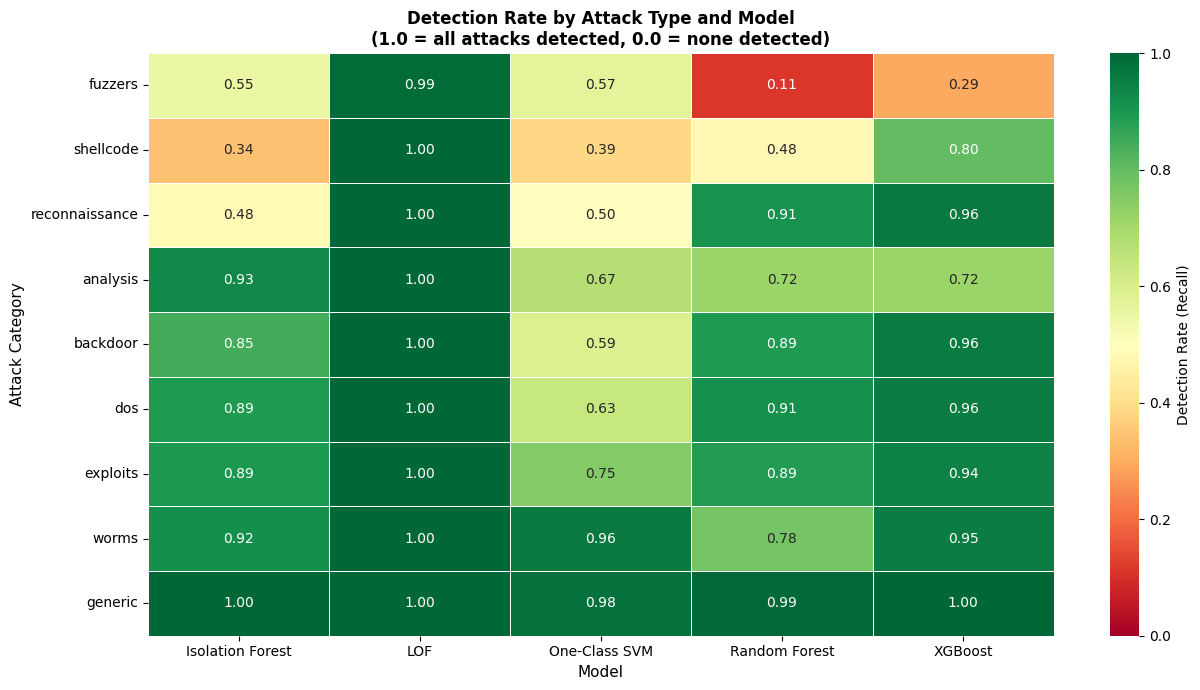

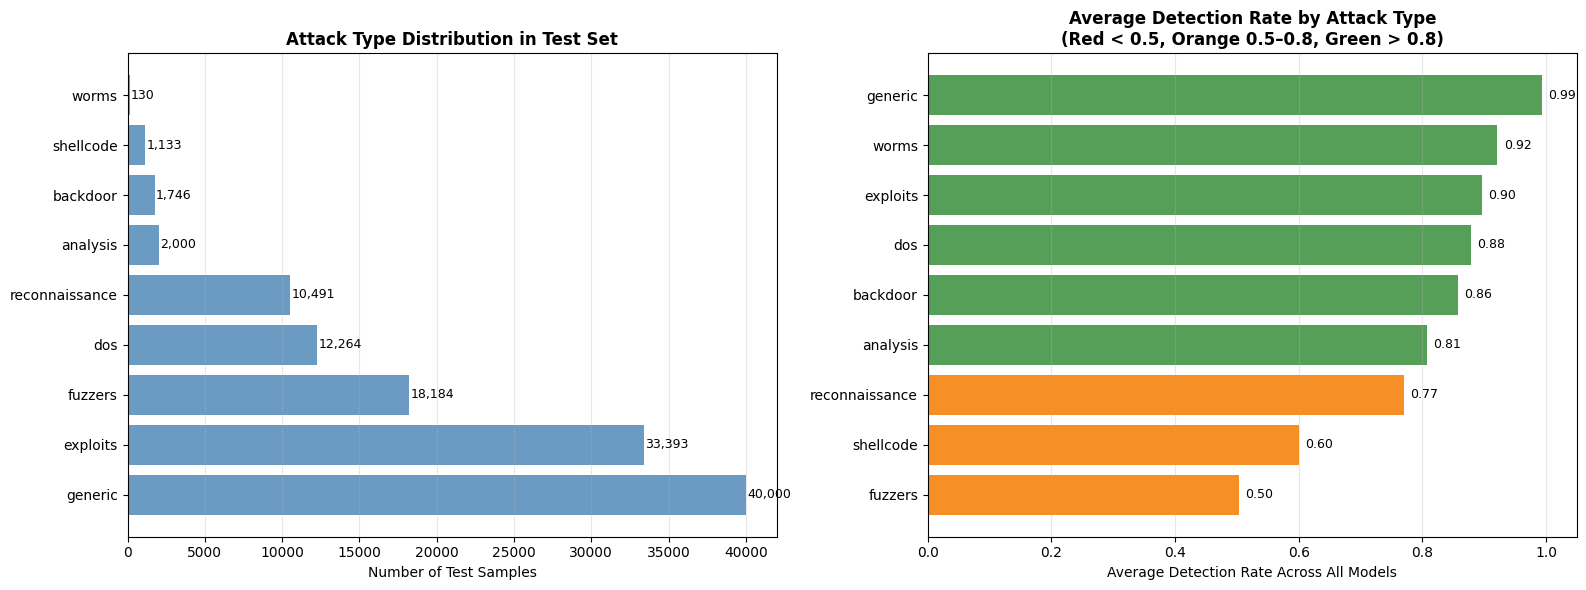

In [18]:
# Get attack category labels from the original test data
attack_categories = test_data['attack_cat'].str.strip().str.lower().copy()

# Map predictions to the test set index (test_data and y_test share the same index)
pred_dict = {
    'Isolation Forest': y_pred_if,
    'LOF': y_pred_lof,
    'One-Class SVM': y_pred_ocsvm,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
}

# Build a results DataFrame
results_df = pd.DataFrame({
    'true_label': y_test.values,
    'attack_cat': attack_categories.values,
})
for model_name, preds in pred_dict.items():
    results_df[model_name] = preds

# Get unique attack categories (excluding normal)
attack_cats = sorted(results_df[results_df['true_label'] == 1]['attack_cat'].unique())

# Calculate detection rate (recall) per attack type per model
detection_rates = {}
category_counts = {}

for cat in attack_cats:
    cat_mask = (results_df['attack_cat'] == cat) & (results_df['true_label'] == 1)
    n_samples = cat_mask.sum()
    category_counts[cat] = n_samples
    rates = {}
    for model_name in pred_dict:
        if n_samples > 0:
            detected = results_df.loc[cat_mask, model_name].sum()
            rates[model_name] = detected / n_samples
        else:
            rates[model_name] = 0.0
    detection_rates[cat] = rates

# Build detection rate DataFrame
detection_df = pd.DataFrame(detection_rates).T
detection_df.index.name = 'Attack Category'

# Add sample counts
detection_df.insert(0, 'Count', [category_counts[c] for c in detection_df.index])

# --- Heatmap of detection rates ---
fig, ax = plt.subplots(figsize=(13, 7))
plot_data = detection_df.drop(columns=['Count'])

# Sort by total detection (hardest to easiest)
plot_data = plot_data.loc[plot_data.mean(axis=1).sort_values().index]

sns.heatmap(plot_data, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=ax, linewidths=0.5, vmin=0, vmax=1,
            cbar_kws={'label': 'Detection Rate (Recall)'})
ax.set_title('Detection Rate by Attack Type and Model\n(1.0 = all attacks detected, 0.0 = none detected)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('Attack Category', fontsize=11)
plt.tight_layout()
plt.show()

# --- Bar chart: attack type counts + average detection ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: sample counts per attack type
sorted_cats = sorted(category_counts, key=category_counts.get, reverse=True)
counts = [category_counts[c] for c in sorted_cats]
axes[0].barh(sorted_cats, counts, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Number of Test Samples')
axes[0].set_title('Attack Type Distribution in Test Set', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')
for i, (cat, cnt) in enumerate(zip(sorted_cats, counts)):
    axes[0].text(cnt + 100, i, f'{cnt:,}', va='center', fontsize=9)

# Right: average detection rate per attack type across all models
avg_detection = detection_df.drop(columns=['Count']).mean(axis=1).sort_values()
bar_colors = ['#d32f2f' if v < 0.5 else '#f57c00' if v < 0.8 else '#388e3c' for v in avg_detection]
axes[1].barh(avg_detection.index, avg_detection.values, color=bar_colors, alpha=0.85)
axes[1].set_xlabel('Average Detection Rate Across All Models')
axes[1].set_title('Average Detection Rate by Attack Type\n(Red < 0.5, Orange 0.5–0.8, Green > 0.8)', fontweight='bold')
axes[1].set_xlim(0, 1.05)
axes[1].grid(True, alpha=0.3, axis='x')
for i, val in enumerate(avg_detection):
    axes[1].text(val + 0.01, i, f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 8.3 Precision-Recall Trade-off Analysis

Examine the precision-recall trade-offs for intrusion detection systems.

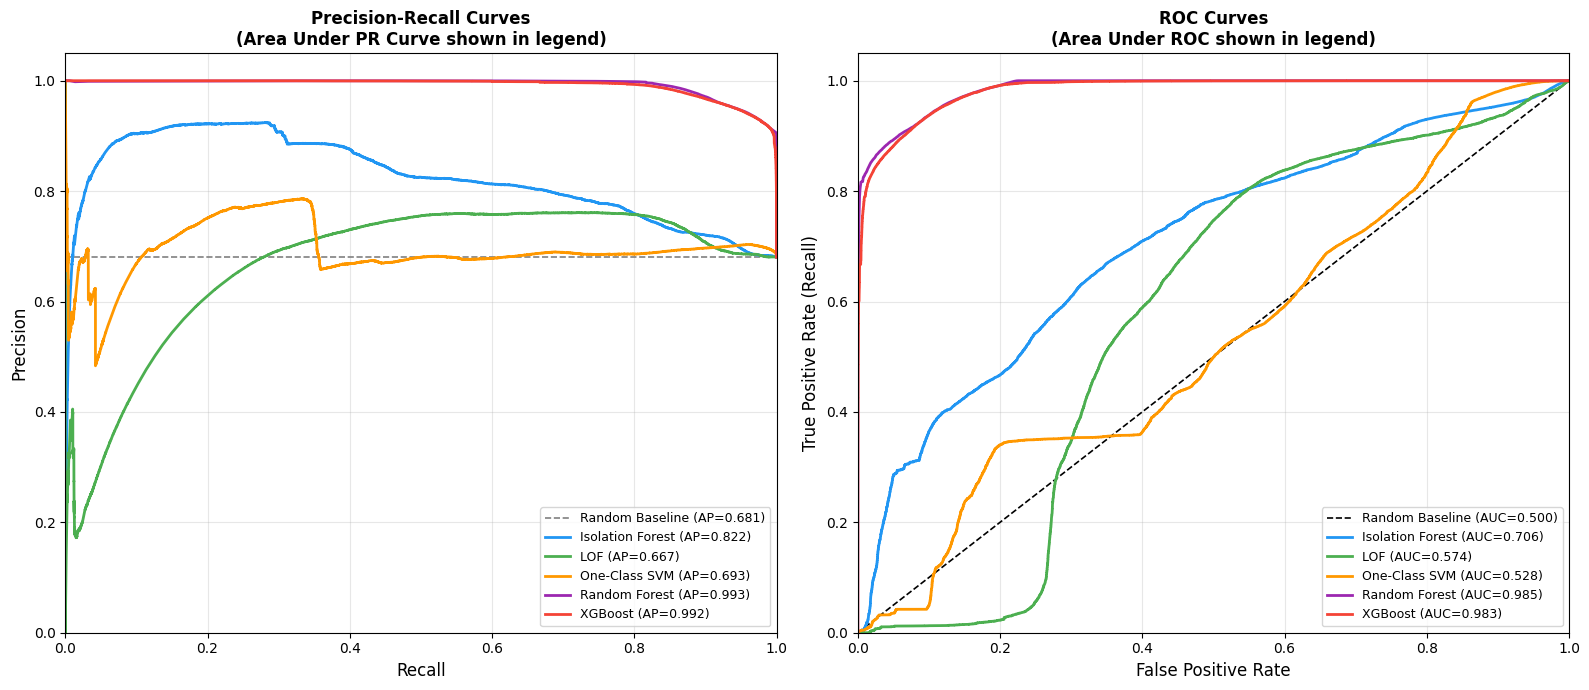

In [19]:
# Anomaly detectors use anomaly scores; supervised use predicted probabilities
score_dict = {
    'Isolation Forest': anomaly_scores,
    'LOF': anomaly_scores_lof,
    'One-Class SVM': anomaly_scores_ocsvm,
    'Random Forest': y_prob_rf,
    'XGBoost': y_prob_xgb,
}

colors = {
    'Isolation Forest': '#2196F3',
    'LOF': '#4CAF50',
    'One-Class SVM': '#FF9800',
    'Random Forest': '#9C27B0',
    'XGBoost': '#F44336',
}

# Compute PR and ROC curves for all models
pr_curves = {}
roc_curves = {}
auprc_scores = {}
auroc_scores = {}

for model_name, scores in score_dict.items():
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, scores)
    fpr_curve, tpr_curve, _ = roc_curve(y_test, scores)
    ap = average_precision_score(y_test, scores)
    auroc = auc(fpr_curve, tpr_curve)

    pr_curves[model_name] = (precision_curve, recall_curve)
    roc_curves[model_name] = (fpr_curve, tpr_curve)
    auprc_scores[model_name] = ap
    auroc_scores[model_name] = auroc

# --- Plot PR Curves ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Baseline: random classifier AUPRC = fraction of positives
baseline_auprc = y_test.mean()
axes[0].axhline(y=baseline_auprc, color='gray', linestyle='--', linewidth=1.2,
                label=f'Random Baseline (AP={baseline_auprc:.3f})')

for model_name, (prec, rec) in pr_curves.items():
    axes[0].plot(rec, prec, color=colors[model_name], linewidth=2,
                 label=f'{model_name} (AP={auprc_scores[model_name]:.3f})')

axes[0].set_xlabel('Recall', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('Precision-Recall Curves\n(Area Under PR Curve shown in legend)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9, loc='lower right')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])

# --- Plot ROC Curves ---
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Random Baseline (AUC=0.500)')

for model_name, (fpr_c, tpr_c) in roc_curves.items():
    axes[1].plot(fpr_c, tpr_c, color=colors[model_name], linewidth=2,
                 label=f'{model_name} (AUC={auroc_scores[model_name]:.3f})')

axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[1].set_title('ROC Curves\n(Area Under ROC shown in legend)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9, loc='lower right')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

### 8.4 Computational Efficiency Comparison

Compare training time, prediction time, and memory requirements across methods.

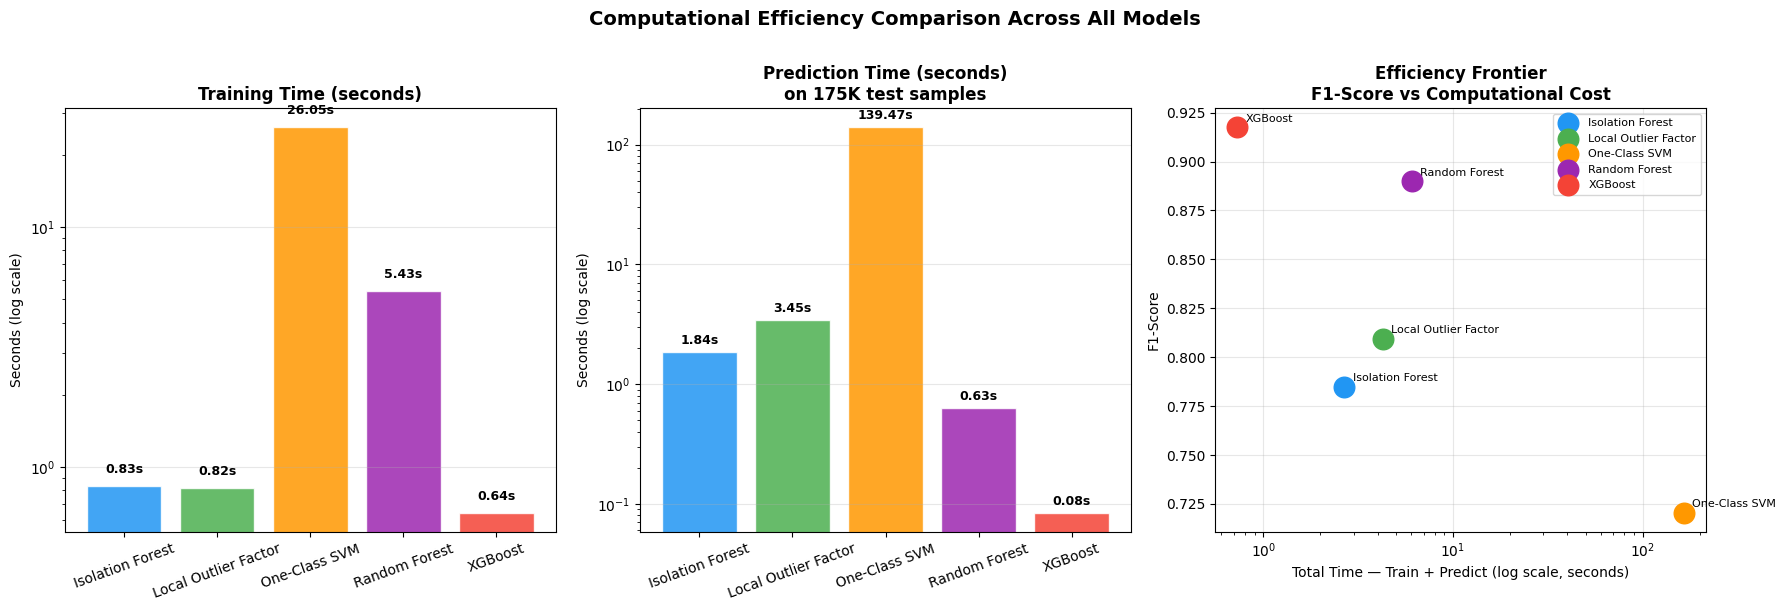

In [20]:
# Collect timing data
timing_data = {
    r['model']: {'Train Time (s)': r['train_time'], 'Predict Time (s)': r['predict_time']}
    for r in all_results
}
timing_df = pd.DataFrame(timing_data).T
timing_df['Total Time (s)'] = timing_df['Train Time (s)'] + timing_df['Predict Time (s)']
timing_df['Predict/Sample (ms)'] = (timing_df['Predict Time (s)'] / len(y_test)) * 1000

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
model_names = timing_df.index.tolist()
colors_timing = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

# Plot 1: Training Time
bars1 = axes[0].bar(model_names, timing_df['Train Time (s)'], color=colors_timing, alpha=0.85, edgecolor='white')
axes[0].set_title('Training Time (seconds)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Seconds')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_yscale('log')
axes[0].set_ylabel('Seconds (log scale)')
for bar, val in zip(bars1, timing_df['Train Time (s)']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                 f'{val:.2f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: Prediction Time
bars2 = axes[1].bar(model_names, timing_df['Predict Time (s)'], color=colors_timing, alpha=0.85, edgecolor='white')
axes[1].set_title('Prediction Time (seconds)\non 175K test samples', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Seconds (log scale)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_yscale('log')
for bar, val in zip(bars2, timing_df['Predict Time (s)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                 f'{val:.2f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 3: F1-Score vs Total Time scatter (efficiency frontier)
f1_scores = [r['f1_score'] for r in all_results]
total_times = timing_df['Total Time (s)'].values

for i, model in enumerate(model_names):
    axes[2].scatter(total_times[i], f1_scores[i], s=220, color=colors_timing[i],
                    zorder=5, label=model)
    axes[2].annotate(model, (total_times[i], f1_scores[i]),
                     textcoords='offset points', xytext=(6, 4), fontsize=8)

axes[2].set_xscale('log')
axes[2].set_xlabel('Total Time — Train + Predict (log scale, seconds)', fontsize=10)
axes[2].set_ylabel('F1-Score', fontsize=10)
axes[2].set_title('Efficiency Frontier\nF1-Score vs Computational Cost', fontweight='bold', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=8, loc='upper right')

plt.suptitle('Computational Efficiency Comparison Across All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()



### 8.5 Key Findings Summary

#### Overall Performance Rankings

Based on our comprehensive evaluation across all five models, the rankings are clear:

| Rank | Model | F1-Score | ROC-AUC | FPR | Total Time |
|------|-------|----------|---------|-----|------------|
| 1 | **XGBoost** | **0.917** | 0.983 | 0.035 | ~0.7s |
| 2 | **Random Forest** | 0.890 | **0.985** | **0.003** | ~6.1s |
| 3 | Isolation Forest | 0.785 | 0.706 | 0.625 | ~2.7s |
| 4 | Local Outlier Factor | 0.809 | 0.574 | 0.998 | ~4.3s |
| 5 | One-Class SVM | 0.721 | 0.528 | 0.743 | ~166s |

*\*Ranked by overall operational viability, not F1 alone. LOF ranks below Isolation Forest despite a marginally higher F1 (0.809 vs. 0.785) because its FPR of 99.8% makes it operationally unusable — it flags virtually every connection as an attack, rendering any discriminative signal meaningless in practice.*

#### Finding 1: Supervised Methods Substantially Outperform Unsupervised Anomaly Detection

The two supervised baselines dominated across every meaningful metric. XGBoost achieved an F1-score of **0.917** and ROC-AUC of **0.983**, compared to the best unsupervised method (Isolation Forest, F1=0.785, ROC-AUC=0.706). The gap is even more pronounced in the precision-recall curves: Random Forest (AUPRC=0.993) and XGBoost (AUPRC=0.992) far exceeded Isolation Forest (AUPRC=0.822) and the density-based methods (LOF=0.667, OCSVM=0.693). This confirms that when labeled attack data is available—even in small quantities—supervised learning provides substantially better discrimination.

#### Finding 2: Distribution Shift Severely Impacts Density-Based Methods

The UNSW-NB15 dataset's temporal train/test split creates a distribution shift that exposes a fundamental weakness of density- and kernel-based anomaly detectors. LOF and One-Class SVM both suffered catastrophic false positive rates (99.8% and 74.3% respectively), while tree-based Isolation Forest was more robust (FPR=62.5%). This occurs because LOF and OCSVM define "normalcy" by the density structure of training data—when test normal traffic evolves, their decision boundaries become invalid. Isolation Forest's path-length mechanism is comparatively insensitive to distributional shifts, making it the most robust anomaly detector in this setting.

#### Finding 3: Isolation Forest is the Best Unsupervised Option

Among the three unsupervised methods, Isolation Forest is the clear winner. It achieved the highest overall discrimination (ROC-AUC=0.706 vs. 0.574 for LOF and 0.528 for OCSVM), maintained a meaningful precision of 0.74, and remained practical (total time ~2.7s). Importantly, its precision-recall curve held above the random baseline across the full recall range (AUPRC=0.822), indicating genuine discriminative ability. By contrast, OCSVM showed near-random ROC-AUC (0.528) and was the slowest model by far (~166 seconds total).

#### Finding 4: Supervised Methods Struggle with Rare Attack Types—Anomaly Detection Excels

The attack type analysis reveals a nuanced story where anomaly detectors have a meaningful advantage for rare attacks. Random Forest detected only **11%** of Fuzzers (the largest category at 18,184 samples) and 48% of Shellcode—dramatic failures suggesting class imbalance overwhelmed the supervised model for these categories. XGBoost improved on RF for these cases (Fuzzers=29%, Shellcode=80%). For Generic attacks (40,000 samples), all five models achieved ≥98% detection, confirming that large, well-represented categories are easy for everyone.

### 8.6 Answer to the Research Question

**"How well do different anomaly detection methods perform on network intrusion detection with extreme class imbalance?"**

Unsupervised anomaly detection methods perform adequately but are significantly limited under real-world conditions. Isolation Forest—the best unsupervised method—achieved an F1 of 0.785 and ROC-AUC of 0.706, demonstrating genuine but imperfect discriminative ability. LOF and One-Class SVM were severely degraded by dataset distribution shift. When labeled data is available, supervised methods (XGBoost F1=0.917, RF F1=0.890) outperform all unsupervised methods by a wide margin.

However, anomaly detection remains valuable for detecting **novel attack types** not seen during training, and for environments where labeled attack data is unavailable or too sparse for supervised learning. The critical lesson is that method selection must account for dataset stability: density-based methods require stable training distributions, while tree-based isolation methods are more robust to the inevitable drift in real-world network traffic.

---

## 9. Conclusion

### 9.1 Summary

As detailed in Section 8.5, supervised methods substantially outperformed unsupervised anomaly detection across all metrics — XGBoost (F1=0.917) and Random Forest (F1=0.890) vs. Isolation Forest's best-unsupervised F1 of 0.785. The headline lesson is that **~13 F1 points separates supervised from unsupervised**, and that gap widens dramatically in false positive rate (0.3% vs. 62.5%). Among unsupervised methods, only Isolation Forest remained viable under the dataset's temporal distribution shift; LOF and OCSVM were severely degraded by it.

---

### 9.2 Practical Implications

**When to use each model:**
- **Labeled data available → XGBoost** (best F1, fastest inference) or **Random Forest** (lowest FPR=0.3%, best for minimal alert fatigue)
- **No labeled data available → Isolation Forest** (robust to distribution shift, trains in <1s, scales well)
- **Avoid LOF / OCSVM** in production settings with large, evolving datasets — both are brittle to concept drift
- **Novel / zero-day attack detection:** Isolation Forest (trained on normal-only) will flag attack types that supervised models have never seen

---

### 9.3 Limitations

- **Static training data:** Models require periodic retraining as network traffic evolves — no online learning was implemented
- **Distribution shift:** UNSW-NB15's temporal train/test split disproportionately penalized density-based methods; their true capability may be higher on stable, representative splits
- **Limited hyperparameter tuning:** Consistent parameters were used across models for fair comparison; per-model optimization (especially for OCSVM's `nu`/`gamma` and LOF's `n_neighbors`) could improve results
- **Binary classification only:** Multi-class attack categorization would provide richer operational value

---

### 9.4 Future Work

- **Hybrid ensemble:** Isolation Forest (novelty detection) + XGBoost (known attack classification) as a two-stage pipeline
- **Online/streaming detection:** Incremental learning algorithms (Hoeffding Trees, streaming LOF) to handle concept drift without full retraining
- **Deep learning:** Autoencoders and LSTM-based detectors for temporal/sequential patterns, particularly for slow-burn attacks
- **Class-specific tuning:** Address RF/XGBoost failures on Fuzzers (11%/29% recall) via targeted oversampling or cost-sensitive learning

---

### 9.5 Final Thoughts

This project demonstrates that **method selection must be driven by operational context** — the availability of labeled data, tolerance for false positives, and exposure to novel attack types. Supervised methods dominate when labels exist, but anomaly detection fills an irreplaceable niche for unknown threats. The sharp divergence between Isolation Forest (robust, tree-based) and LOF/OCSVM (brittle, density-based) under distribution shift is the most important practical takeaway: not all anomaly detectors are equally resilient, and matching algorithm assumptions to dataset properties matters as much as the algorithm choice itself.

---

## Appendix

```
On my honor, I declare the following resources:

1. Collaborators: N/A

2. Web Sources:
   - UNSW-NB15 dataset documentation: https://research.unsw.edu.au/projects/unsw-nb15-dataset
   - scikit-learn documentation: https://scikit-learn.org/stable/
   - XGBoost documentation: https://xgboost.readthedocs.io/

3. AI Tools:
- GitHub Copilot (Claude Sonnet 4.6) was used extensively throughout this project. It helped generate a brief recap of Checkpoints 1 & 2 for context, re-implement the data preprocessing pipeline, scaffold the training and evaluation code for each model with formatted output, refine the written analysis in the markdown cells for clarity and depth, assist with the overall formatting and structure of the notebook for consistency and readability, and serve as a resource for answering questions that came up along the way.

4. Citations:
- Moustafa, Nour, and Jill Slay. "UNSW-NB15: a comprehensive data set for network intrusion detection systems (UNSW-NB15 network data set)." Military Communications and Information Systems Conference (MilCIS), 2015. IEEE, 2015.
- Moustafa, Nour, and Jill Slay. "The evaluation of Network Anomaly Detection Systems: Statistical analysis of the UNSW-NB15 dataset and the comparison with the KDD99 dataset." Information Security Journal: A Global Perspective (2016): 1-14.
- Moustafa, Nour, et al. "Novel geometric area analysis technique for anomaly detection using trapezoidal area estimation on large-scale networks." IEEE Transactions on Big Data (2017).
- Moustafa, Nour, et al. "Big data analytics for intrusion detection system: statistical decision-making using finite dirichlet mixture models." Data Analytics and Decision Support for Cybersecurity. Springer, Cham, 2017. 127-156.
- Sarhan, Mohanad, Siamak Layeghy, Nour Moustafa, and Marius Portmann. NetFlow Datasets for Machine Learning-Based Network Intrusion Detection Systems. In Big Data Technologies and Applications: 10th EAI International Conference, BDTA 2020, and 13th EAI International Conference on Wireless Internet, WiCON 2020, Virtual Event, December 11, 2020, Proceedings (p. 117). Springer Nature.
```
